In [3]:
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

Loaded session_05Apr26_0459H.bin | total samples per channel: 5,083,975
Window 1: start_sample=0, end_sample=20,000, sample_count=20,000
Window 2: start_sample=20,000, end_sample=40,000, sample_count=20,000
Window 3: start_sample=40,000, end_sample=60,000, sample_count=20,000

Window 1 | anchor channel=CH4 | detected_rpeaks=65
  Segmenting CH2 using CH4 R-peaks...
  Segmenting CH3 using CH4 R-peaks...
  Segmenting CH4 using CH4 R-peaks...


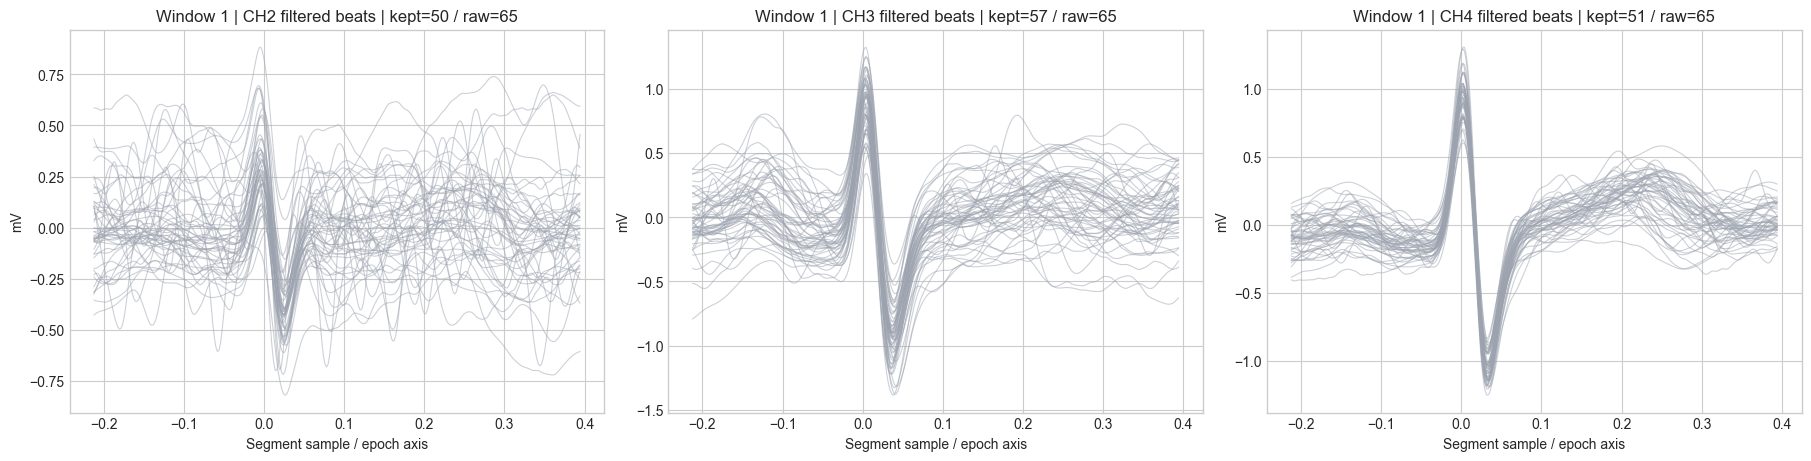

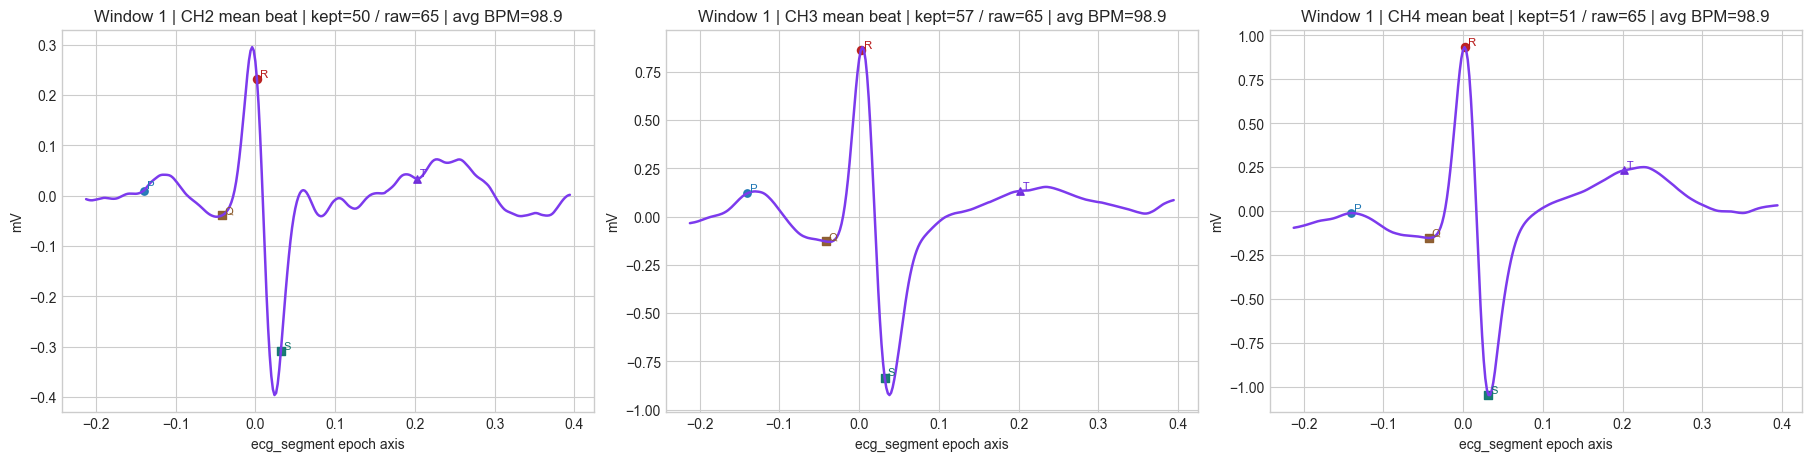


Window 2 | anchor channel=CH4 | detected_rpeaks=78
  Segmenting CH2 using CH4 R-peaks...
  Segmenting CH3 using CH4 R-peaks...
  Segmenting CH4 using CH4 R-peaks...


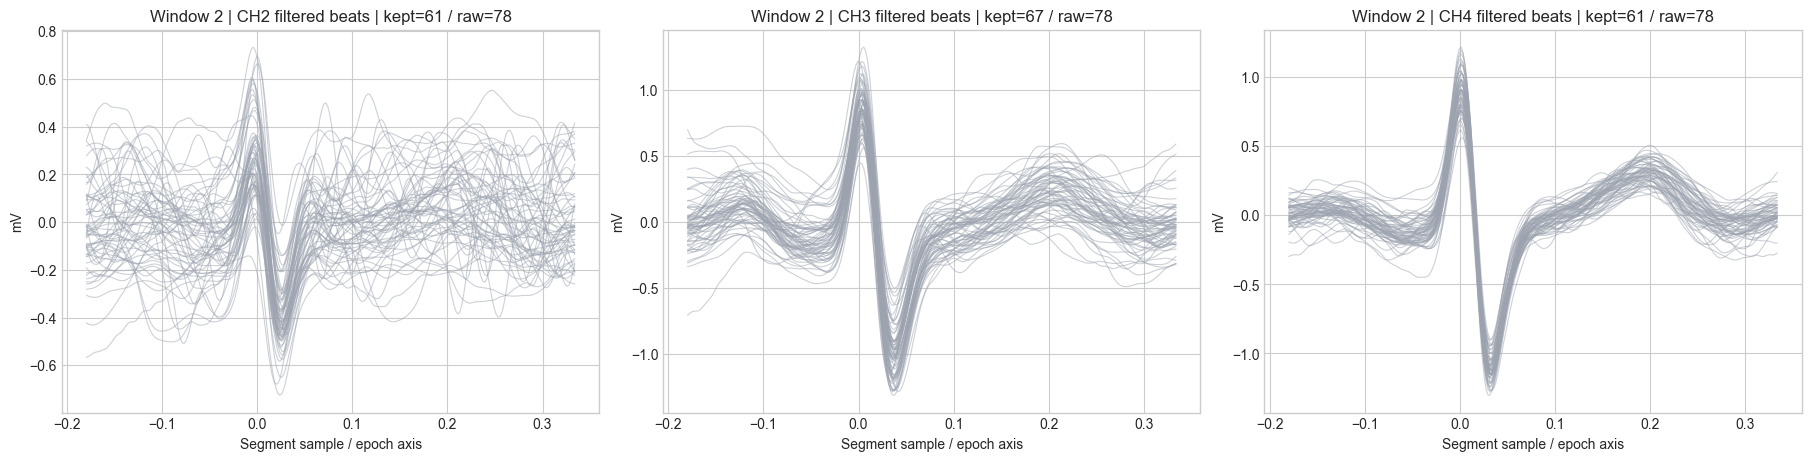

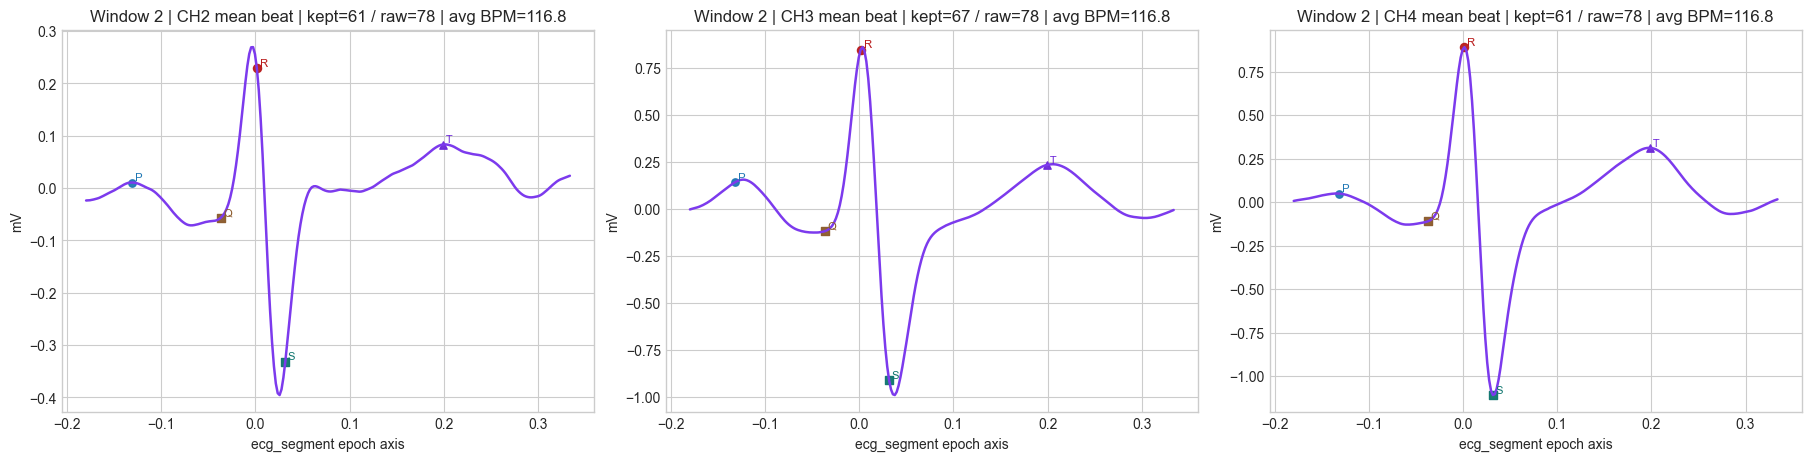


Window 3 | anchor channel=CH4 | detected_rpeaks=83
  Segmenting CH2 using CH4 R-peaks...
  Segmenting CH3 using CH4 R-peaks...
  Segmenting CH4 using CH4 R-peaks...


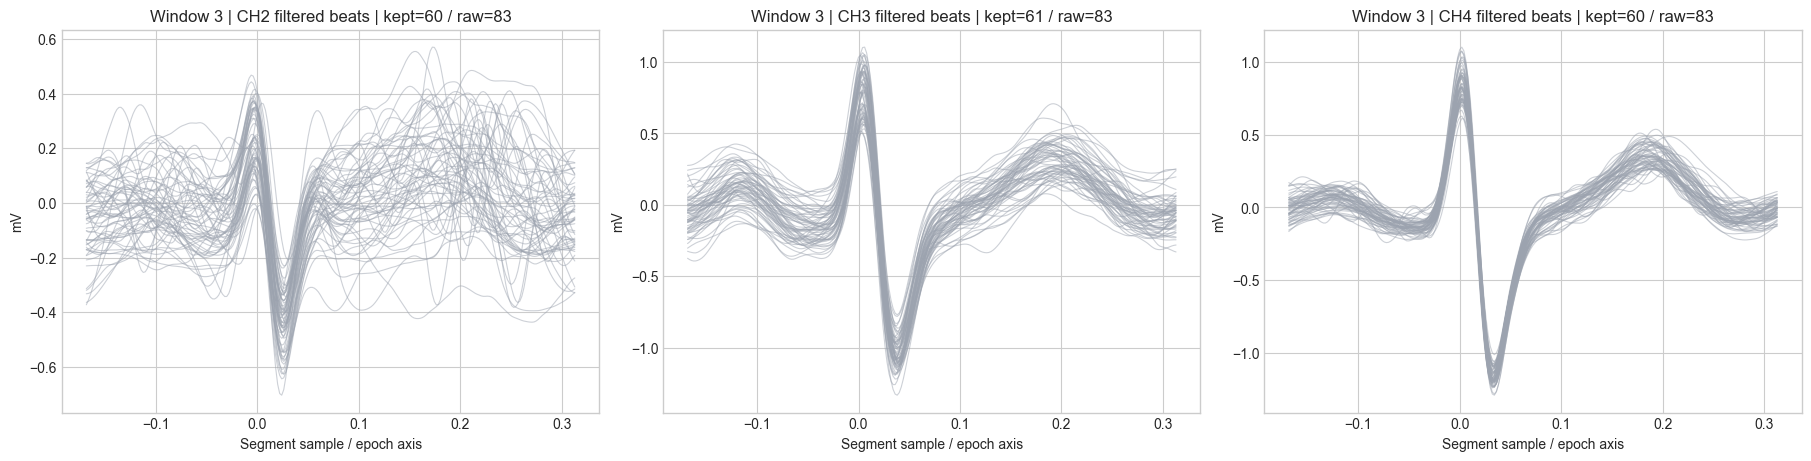

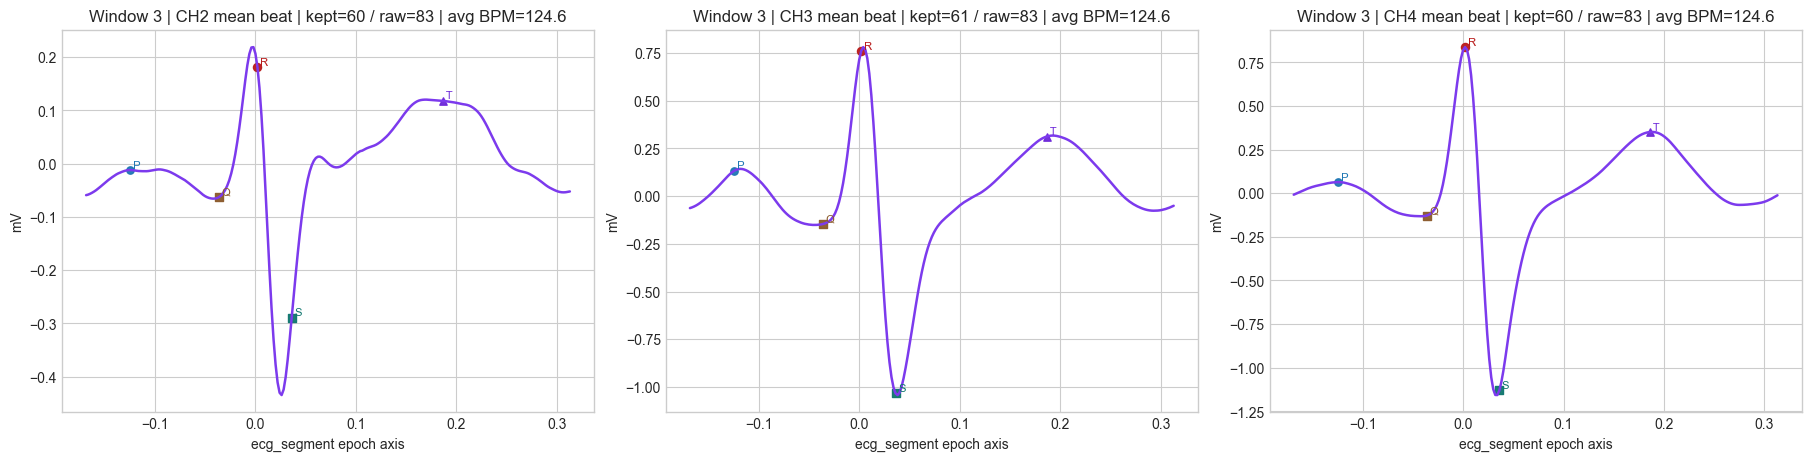

In [4]:
RAW_FILE = Path("session_05Apr26_0459H.bin")
PACKET_BYTES = 231
STATUS_BYTES = 3
SAMPLES_PER_PACKET = 25
CHANNEL_LABELS = ["CH2", "CH3", "CH4"]
BYTES_PER_SAMPLE = 3
WINDOW_SAMPLES = 10_000
ADS1298_VREF = 2.4
ADS1298_GAIN = 6
ADS1298_MAX_CODE = (2**23) - 1
ANCHOR_CHANNEL = "CH4"
SAMPLING_RATE = 500
BEAT_OUTLIER_Z_THRESHOLD = 2.5


def read24_signed_be(buffer: bytes, offset: int) -> int:
    value = (buffer[offset] << 16) | (buffer[offset + 1] << 8) | buffer[offset + 2]
    if value & 0x800000:
        value -= 0x1000000
    return value


def counts_to_mv(count: int) -> float:
    return (count / ADS1298_MAX_CODE) * (ADS1298_VREF / ADS1298_GAIN) * 1000.0


def decode_ads1298_packets(payload: bytes) -> Dict[str, np.ndarray]:
    packet_count = len(payload) // PACKET_BYTES
    channels: Dict[str, List[float]] = {label: [] for label in CHANNEL_LABELS}

    for packet_index in range(packet_count):
        base = packet_index * PACKET_BYTES
        offset = base + STATUS_BYTES
        for label in CHANNEL_LABELS:
            for _ in range(SAMPLES_PER_PACKET):
                channels[label].append(counts_to_mv(read24_signed_be(payload, offset)))
                offset += BYTES_PER_SAMPLE

    return {label: np.asarray(values, dtype=np.float64) for label, values in channels.items()}


def segmented_beats_to_matrix(segments: Dict[str, 'pd.DataFrame']) -> tuple[np.ndarray, np.ndarray]:
    epoch_names = list(segments.keys())
    if not epoch_names:
        return np.array([], dtype=float), np.empty((0, 0), dtype=float)

    epoch_index = np.asarray(segments[epoch_names[0]].index, dtype=float)
    beat_matrix = []
    for epoch_name in epoch_names:
        epoch_df = segments[epoch_name]
        beat_matrix.append(np.asarray(epoch_df["Signal"], dtype=float))

    return epoch_index, np.vstack(beat_matrix)


def build_marker_signal(length: int, positions: np.ndarray) -> np.ndarray:
    marker_signal = np.zeros(length, dtype=float)
    valid_positions = np.asarray(positions, dtype=int)
    valid_positions = valid_positions[(valid_positions >= 0) & (valid_positions < length)]
    marker_signal[valid_positions] = 1.0
    return marker_signal


def sanitize_marker_positions(values) -> np.ndarray:
    if values is None:
        return np.array([], dtype=int)
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.array([], dtype=int)
    return np.asarray(np.round(arr), dtype=int)


def reject_outlier_beats(beat_matrix: np.ndarray, z_threshold: float = 2.5) -> tuple[np.ndarray, np.ndarray]:
    if beat_matrix.size == 0 or beat_matrix.ndim != 2 or beat_matrix.shape[0] < 2:
        keep_mask = np.ones(beat_matrix.shape[0] if beat_matrix.ndim == 2 else 0, dtype=bool)
        return beat_matrix, keep_mask

    sample_mean = np.nanmean(beat_matrix, axis=0)
    sample_std = np.nanstd(beat_matrix, axis=0)
    safe_std = np.where(sample_std > 0, sample_std, np.nan)
    z_scores = np.abs((beat_matrix - sample_mean) / safe_std)
    beat_max_z = np.nanmax(z_scores, axis=1)
    keep_mask = np.where(np.isnan(beat_max_z), True, beat_max_z <= z_threshold)

    if not np.any(keep_mask):
        keep_mask = np.ones(beat_matrix.shape[0], dtype=bool)

    return beat_matrix[keep_mask], keep_mask


payload = RAW_FILE.read_bytes()
channels = decode_ads1298_packets(payload)
total_samples = len(channels["CH2"])

window_ranges = {
    "Window 1": (0, 20_000),
    "Window 2": (20_000, 40_000),
    "Window 3": (40_000, 60_000),
}

print(f"Loaded {RAW_FILE.name} | total samples per channel: {total_samples:,}")
for window_label, (start, end) in window_ranges.items():
    bounded_end = min(total_samples, end)
    print(f"{window_label}: start_sample={start:,}, end_sample={bounded_end:,}, sample_count={max(0, bounded_end - start):,}")

average_beats_by_window = {}

for window_label, (start, end) in window_ranges.items():
    end = min(total_samples, end)
    if end <= start:
        print(f"Skipping {window_label}: invalid sample range.")
        continue

    raw_window = {
        channel_label: channels[channel_label][start:end]
        for channel_label in CHANNEL_LABELS
    }

    processed_anchor_signals, processed_anchor_info = nk.ecg_process(
        raw_window[ANCHOR_CHANNEL],
        sampling_rate=SAMPLING_RATE,
    )
    anchor_rpeaks = np.asarray(processed_anchor_info.get("ECG_R_Peaks", np.array([], dtype=int)), dtype=int)
    average_bpm = float(np.nanmean(np.asarray(processed_anchor_signals["ECG_Rate"], dtype=float)))

    cleaned_window = {
        "CH2": nk.ecg_clean(raw_window["CH2"], sampling_rate=SAMPLING_RATE, method="neurokit"),
        "CH3": nk.ecg_clean(raw_window["CH3"], sampling_rate=SAMPLING_RATE, method="neurokit"),
        "CH4": np.asarray(processed_anchor_signals["ECG_Clean"], dtype=float),
    }

    print()
    print(f"{window_label} | anchor channel={ANCHOR_CHANNEL} | detected_rpeaks={len(anchor_rpeaks):,}")

    anchor_marker_positions = {
        "P": sanitize_marker_positions(processed_anchor_info.get("ECG_P_Peaks", [])),
        "Q": sanitize_marker_positions(processed_anchor_info.get("ECG_Q_Peaks", [])),
        "R": anchor_rpeaks,
        "S": sanitize_marker_positions(processed_anchor_info.get("ECG_S_Peaks", [])),
        "T": sanitize_marker_positions(processed_anchor_info.get("ECG_T_Peaks", [])),
    }

    anchor_marker_profiles = {}
    anchor_marker_indices = {}
    anchor_epoch_axis = None
    for marker_label, marker_positions in anchor_marker_positions.items():
        marker_signal = build_marker_signal(len(raw_window[ANCHOR_CHANNEL]), marker_positions)
        marker_segments = nk.ecg_segment(
            marker_signal,
            rpeaks=anchor_rpeaks,
            sampling_rate=SAMPLING_RATE,
            show=False,
        )
        marker_epoch_axis, marker_matrix = segmented_beats_to_matrix(marker_segments)
        if anchor_epoch_axis is None and len(marker_epoch_axis):
            anchor_epoch_axis = marker_epoch_axis
        if marker_matrix.size == 0:
            anchor_marker_profiles[marker_label] = np.array([], dtype=float)
            anchor_marker_indices[marker_label] = None
        else:
            marker_profile = np.nanmean(marker_matrix, axis=0)
            anchor_marker_profiles[marker_label] = marker_profile
            anchor_marker_indices[marker_label] = int(np.nanargmax(marker_profile)) if np.nanmax(marker_profile) > 0 else None

    average_beats_by_window[window_label] = {
        "start_sample": start,
        "end_sample": end,
        "anchor_rpeaks": anchor_rpeaks,
        "average_bpm": average_bpm,
        "anchor_marker_indices": anchor_marker_indices,
        "anchor_epoch_axis": anchor_epoch_axis,
        "channels": {},
    }

    for channel_label in CHANNEL_LABELS:
        print(f"  Segmenting {channel_label} using {ANCHOR_CHANNEL} R-peaks...")
        segments = nk.ecg_segment(
            cleaned_window[channel_label],
            rpeaks=anchor_rpeaks,
            sampling_rate=SAMPLING_RATE,
            show=False,
        )

        epoch_axis, beat_matrix = segmented_beats_to_matrix(segments)
        filtered_beat_matrix, keep_mask = reject_outlier_beats(beat_matrix, z_threshold=BEAT_OUTLIER_Z_THRESHOLD)
        if filtered_beat_matrix.size == 0:
            mean_beat = np.array([], dtype=float)
        else:
            mean_beat = np.nanmean(filtered_beat_matrix, axis=0)

        average_beats_by_window[window_label]["channels"][channel_label] = {
            "segments": segments,
            "epoch_axis": epoch_axis,
            "beat_matrix": beat_matrix,
            "filtered_beat_matrix": filtered_beat_matrix,
            "keep_mask": keep_mask,
            "mean_beat": mean_beat,
            "n_beats": int(filtered_beat_matrix.shape[0]) if filtered_beat_matrix.ndim == 2 else 0,
            "n_beats_raw": int(beat_matrix.shape[0]) if beat_matrix.ndim == 2 else 0,
        }

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True, constrained_layout=True)
    for axis, channel_label in zip(axes, CHANNEL_LABELS):
        channel_data = average_beats_by_window[window_label]["channels"][channel_label]
        epoch_axis = channel_data["epoch_axis"]
        beat_matrix = channel_data["filtered_beat_matrix"]
        if beat_matrix.size:
            for beat in beat_matrix:
                axis.plot(epoch_axis, beat, color="#9ca3af", linewidth=0.8, alpha=0.5)
        axis.set_title(
            f"{window_label} | {channel_label} filtered beats | kept={channel_data['n_beats']} / raw={channel_data['n_beats_raw']}"
        )
        axis.set_xlabel("Segment sample / epoch axis")
        axis.set_ylabel("mV")
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True, constrained_layout=True)
    marker_indices = average_beats_by_window[window_label]["anchor_marker_indices"]
    for axis, channel_label in zip(axes, CHANNEL_LABELS):
        channel_data = average_beats_by_window[window_label]["channels"][channel_label]
        epoch_axis = channel_data["epoch_axis"]
        mean_beat = channel_data["mean_beat"]
        axis.plot(epoch_axis, mean_beat, color="#7c3aed", linewidth=1.8)

        for marker_label, marker_index in marker_indices.items():
            if marker_index is None or marker_index >= len(epoch_axis) or marker_index >= len(mean_beat):
                continue
            if not np.isfinite(mean_beat[marker_index]):
                continue
            axis.scatter(
                epoch_axis[marker_index],
                mean_beat[marker_index],
                s=28 if marker_label != "R" else 34,
                color={"P": "#1f77b4", "Q": "#8b5a2b", "R": "#b91c1c", "S": "#0f766e", "T": "#6d28d9"}[marker_label],
                marker={"P": "o", "Q": "s", "R": "o", "S": "s", "T": "^"}[marker_label],
                alpha=0.95,
            )
            axis.text(
                epoch_axis[marker_index],
                mean_beat[marker_index],
                f" {marker_label}",
                fontsize=8,
                color={"P": "#1f77b4", "Q": "#8b5a2b", "R": "#b91c1c", "S": "#0f766e", "T": "#6d28d9"}[marker_label],
                va="bottom",
            )

        axis.set_title(
            f"{window_label} | {channel_label} mean beat | kept={channel_data['n_beats']} / raw={channel_data['n_beats_raw']} | avg BPM={average_beats_by_window[window_label]['average_bpm']:.1f}"
        )
        axis.set_xlabel("ecg_segment epoch axis")
        axis.set_ylabel("mV")
    plt.show()









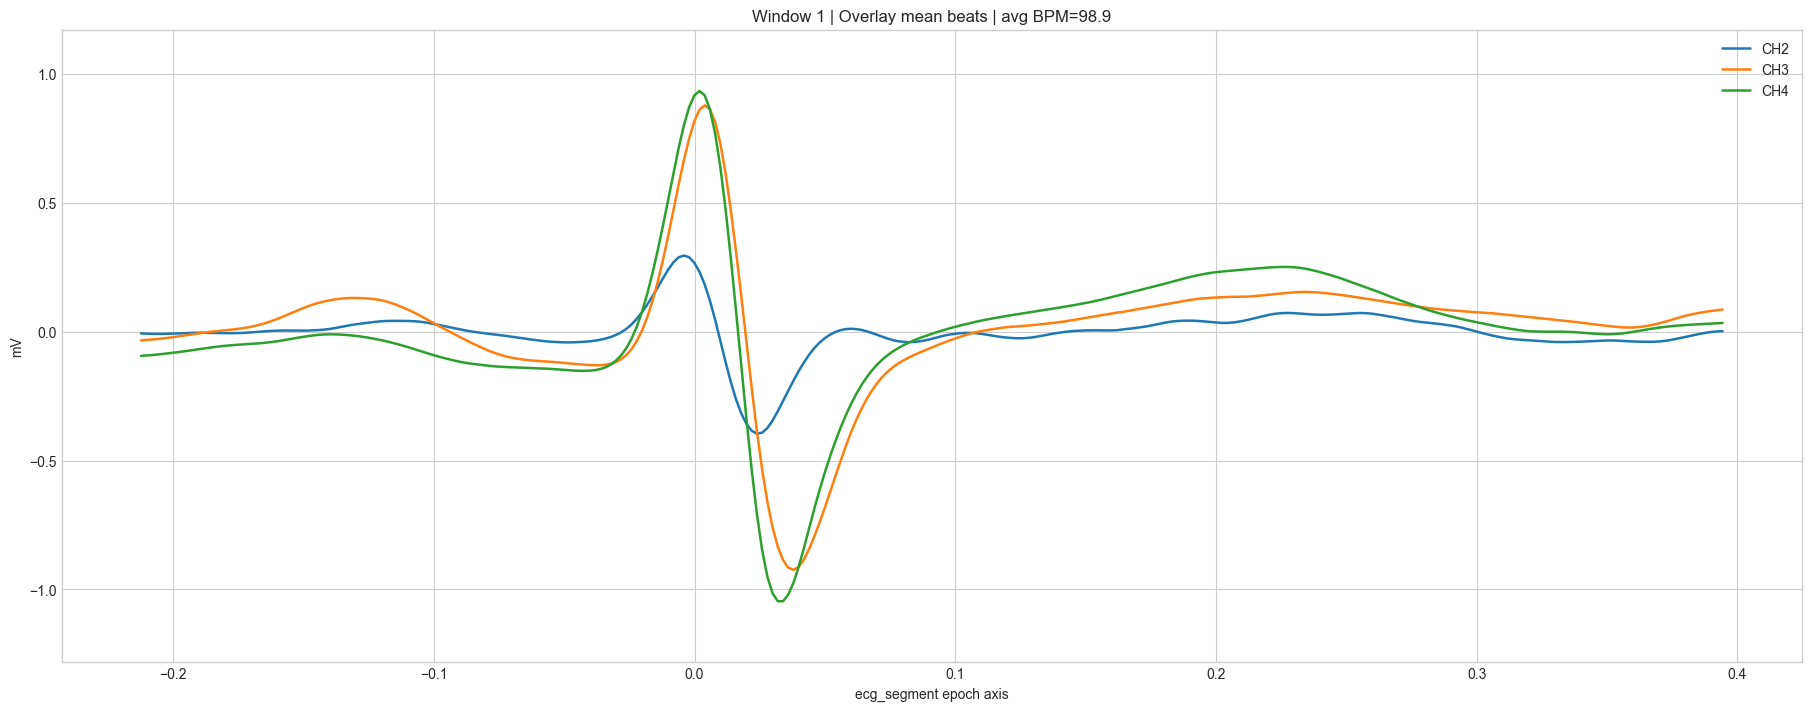

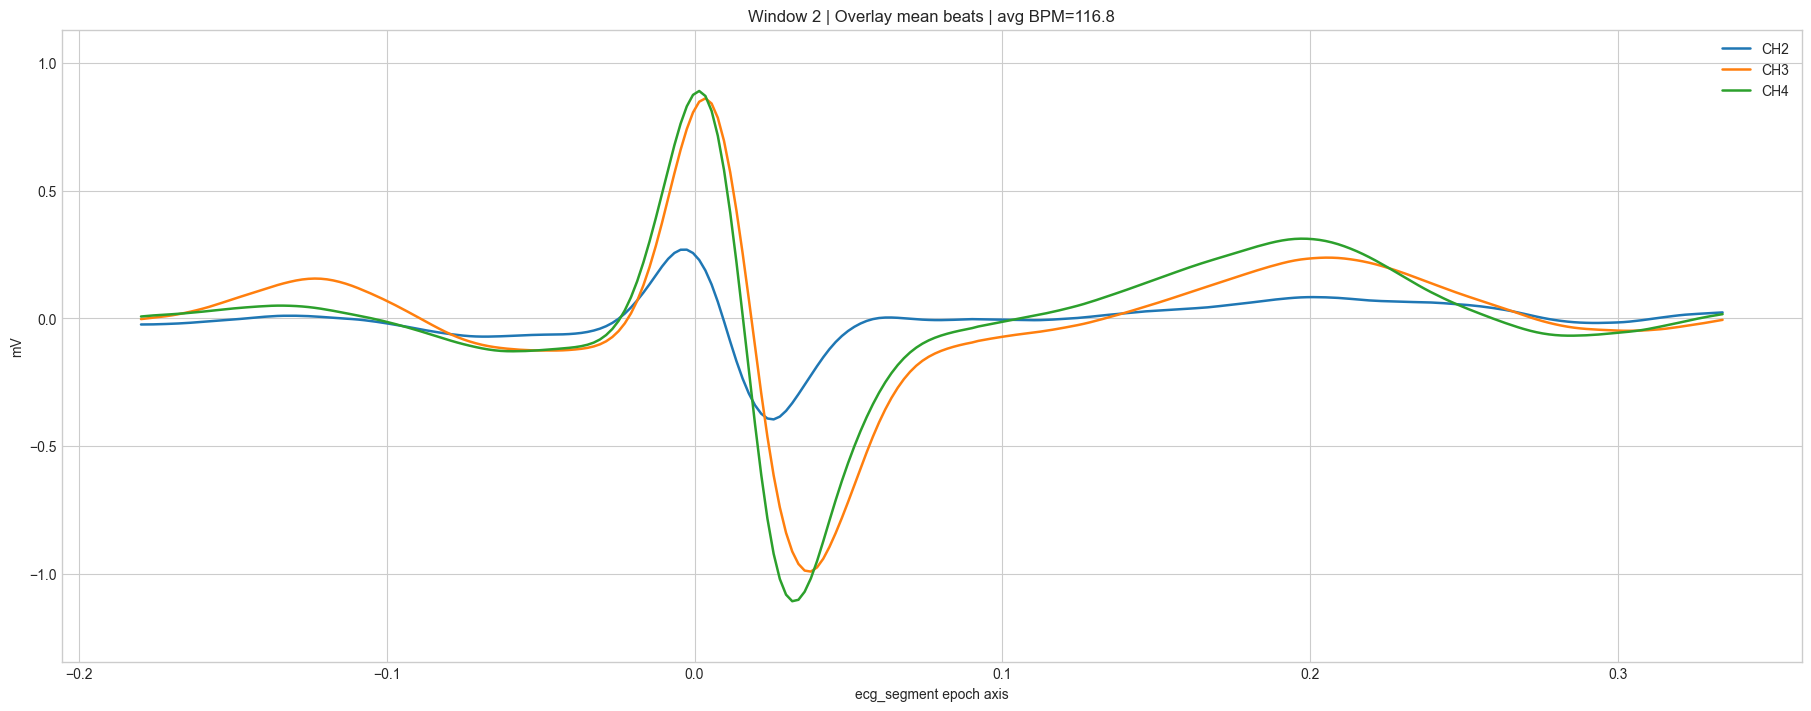

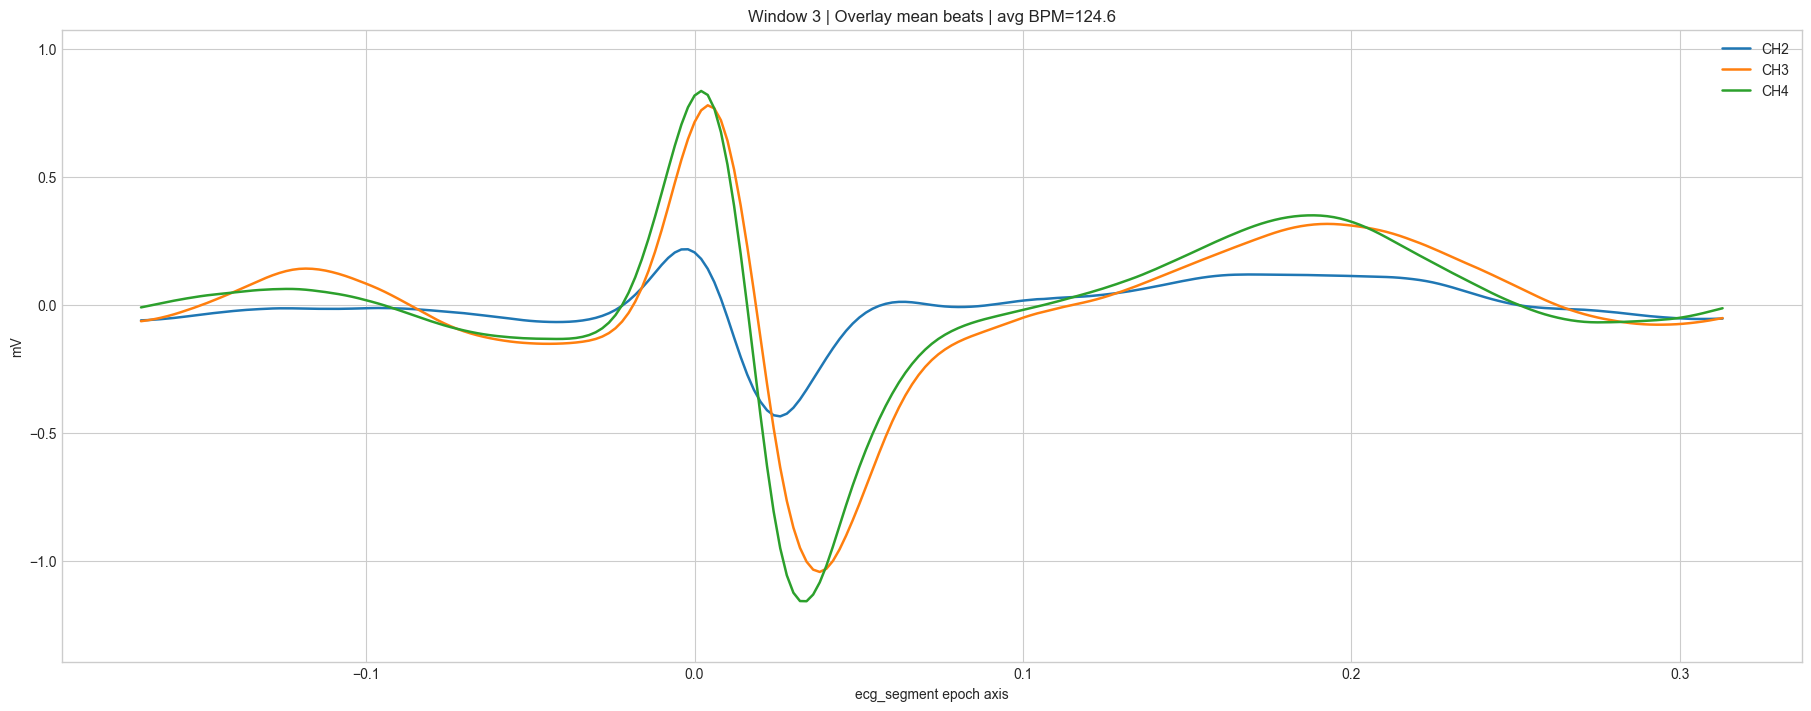

In [ ]:
colors = {"CH2": "#1f77b4", "CH3": "#ff7f0e", "CH4": "#2ca02c"}

for window_label, window_data in average_beats_by_window.items():
    fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)

    all_values = []
    epoch_axis_reference = None
    for channel_label in CHANNEL_LABELS:
        channel_data = window_data["channels"][channel_label]
        epoch_axis = channel_data["epoch_axis"]
        mean_beat = channel_data["mean_beat"]
        if epoch_axis_reference is None:
            epoch_axis_reference = epoch_axis
        if len(mean_beat):
            ax.plot(
                epoch_axis,
                mean_beat,
                color=colors[channel_label],
                linewidth=1.8,
                label=channel_label,
            )
            finite_values = mean_beat[np.isfinite(mean_beat)]
            if len(finite_values):
                all_values.append(finite_values)

    if all_values:
        combined = np.concatenate(all_values)
        y_min = float(np.min(combined))
        y_max = float(np.max(combined))
        y_range = max(y_max - y_min, 1e-6)
        padding = 0.12 * y_range
        ax.set_ylim(y_min - padding, y_max + padding) 

    ax.set_title(f"{window_label} | Overlay mean beats | avg BPM={window_data['average_bpm']:.1f}")
    ax.set_xlabel("ecg_segment epoch axis")
    ax.set_ylabel("mV")
    ax.legend(loc="upper right")
    plt.show()



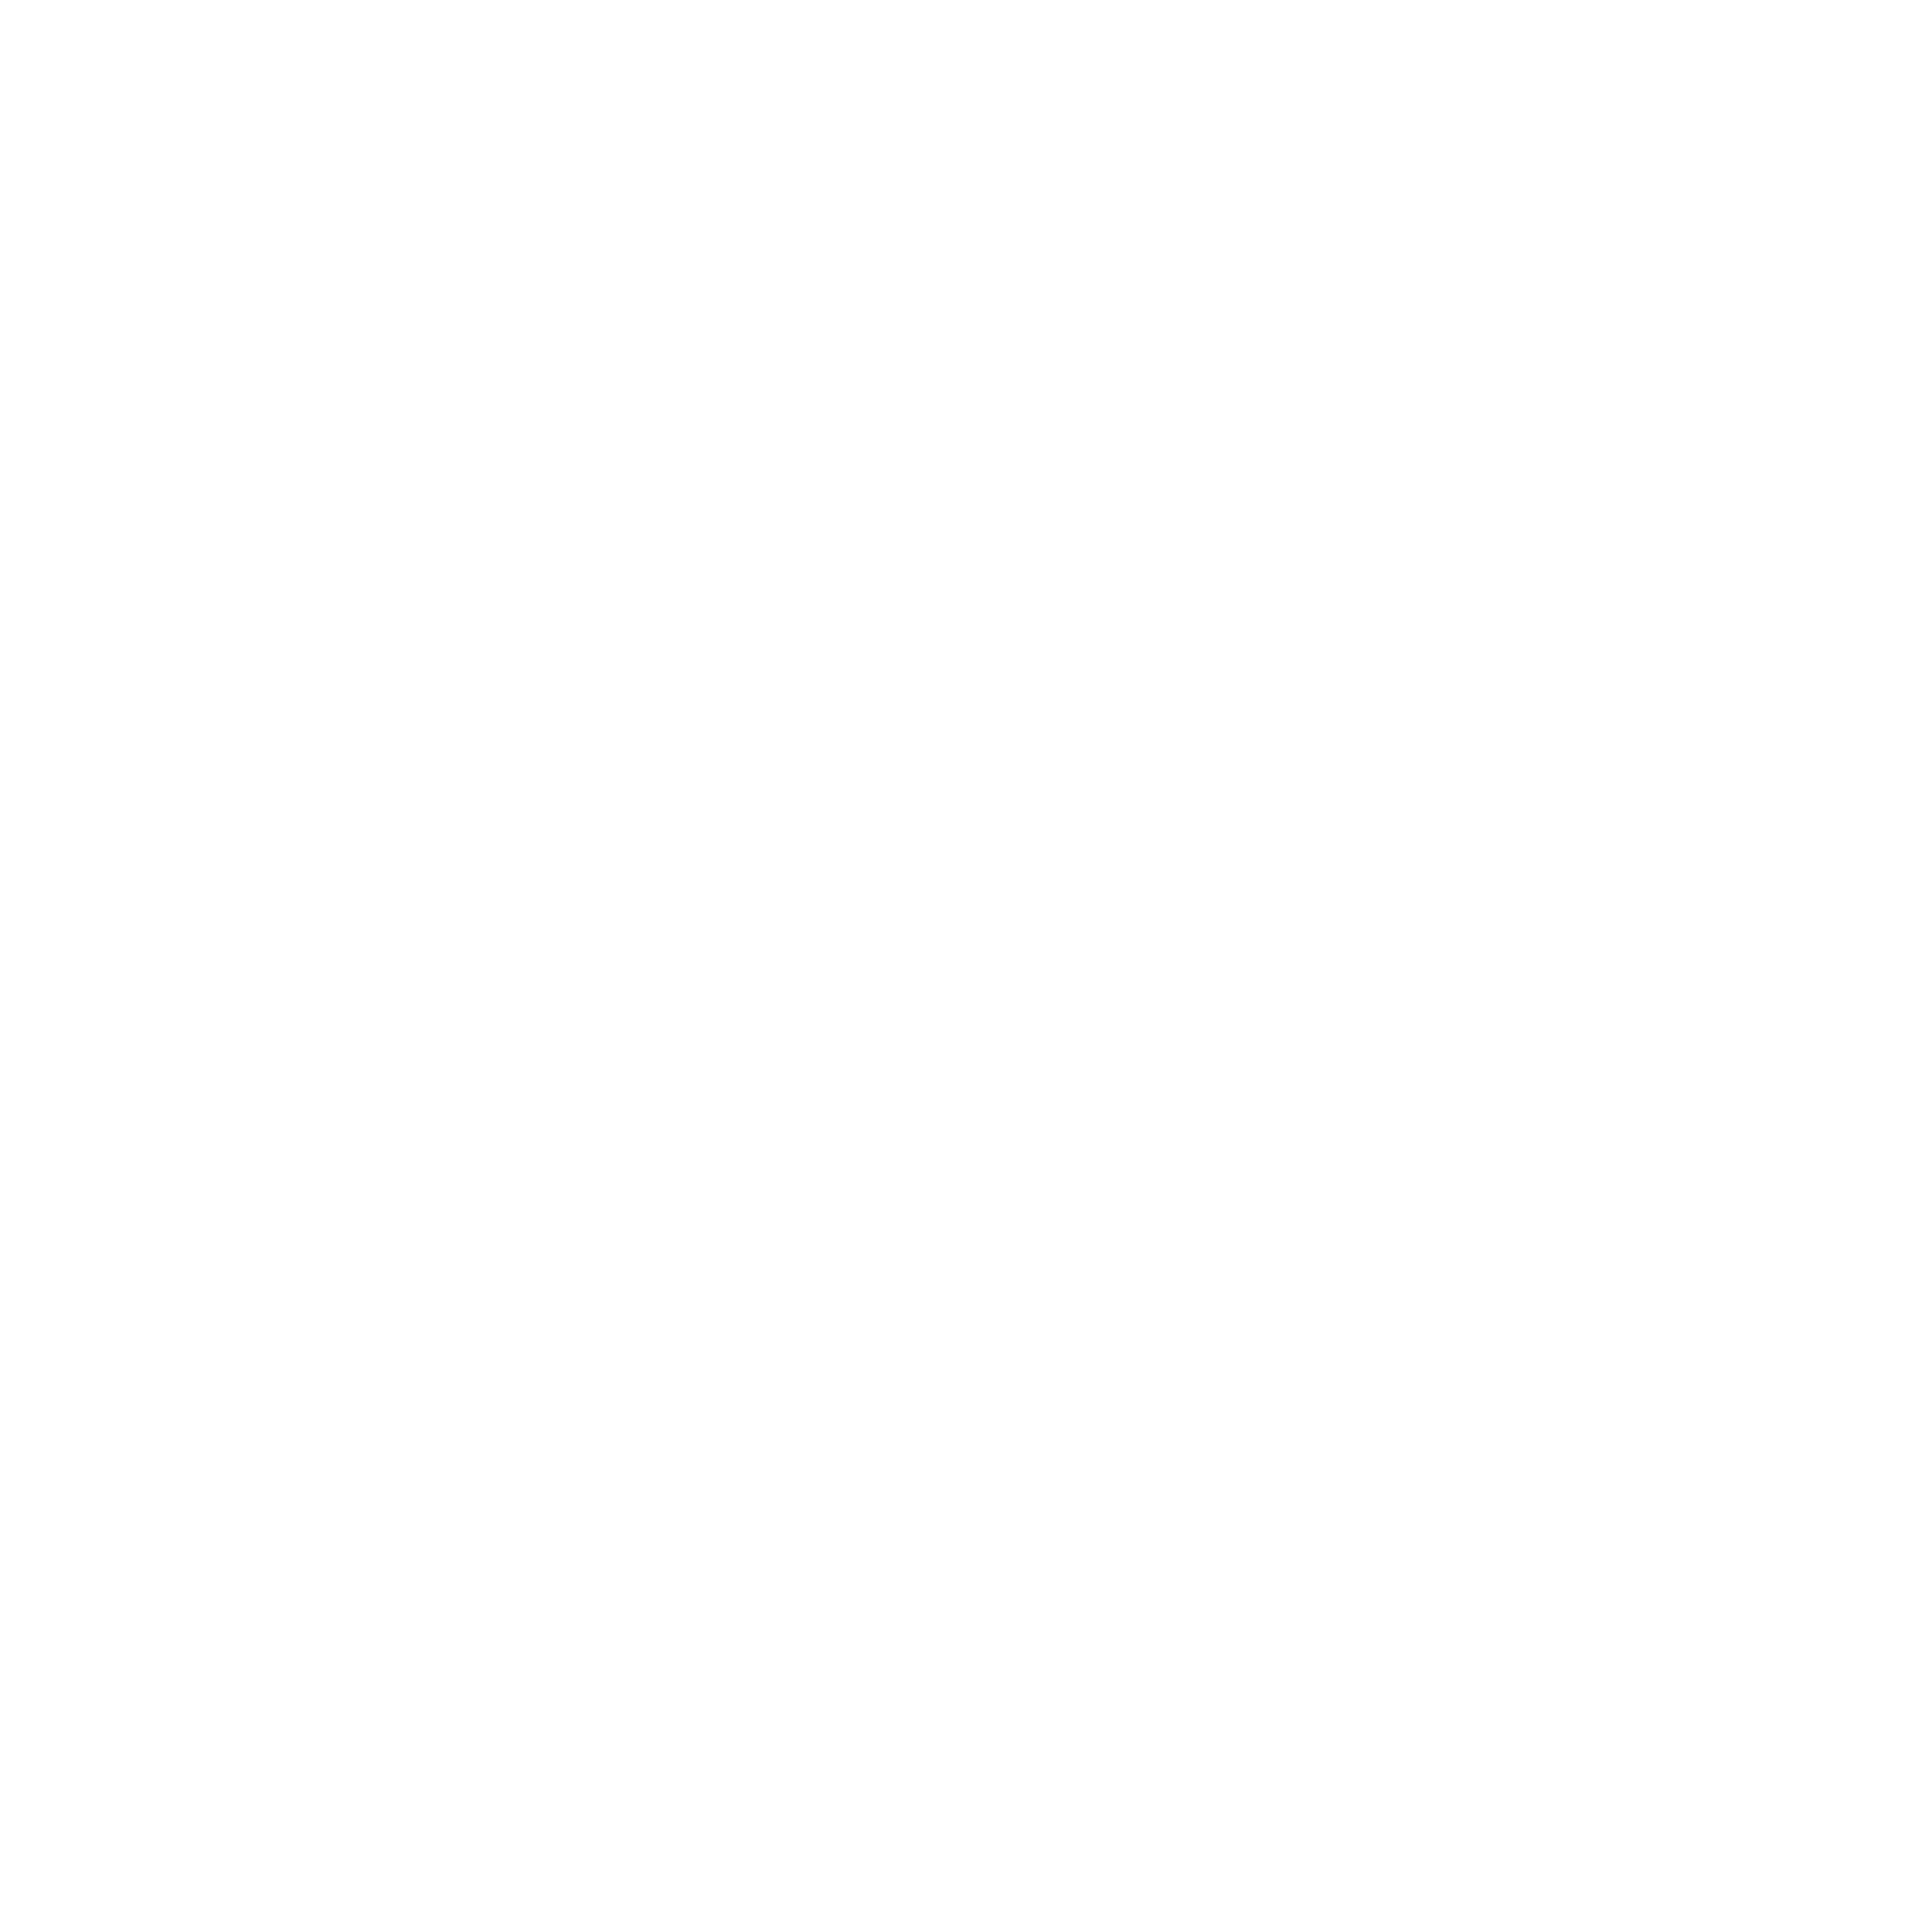

In [6]:
GRID_WINDOW_COUNT = 0
GRID_ROWS = 6
GRID_COLS = 4
TITLE_FONTSIZE = 13

multiwindow_mean_overlays = {}

for window_idx in range(GRID_WINDOW_COUNT):
    start = window_idx * WINDOW_SAMPLES
    end = min(total_samples, start + WINDOW_SAMPLES)
    if end <= start:
        break

    raw_window = {
        channel_label: channels[channel_label][start:end]
        for channel_label in CHANNEL_LABELS
    }

    processed_anchor_signals, processed_anchor_info = nk.ecg_process(
        raw_window[ANCHOR_CHANNEL],
        sampling_rate=SAMPLING_RATE,
    )
    anchor_rpeaks = np.asarray(processed_anchor_info.get("ECG_R_Peaks", np.array([], dtype=int)), dtype=int)
    average_bpm = float(np.nanmean(np.asarray(processed_anchor_signals["ECG_Rate"], dtype=float)))

    cleaned_window = {
        "CH2": nk.ecg_clean(raw_window["CH2"], sampling_rate=SAMPLING_RATE, method="neurokit"),
        "CH3": nk.ecg_clean(raw_window["CH3"], sampling_rate=SAMPLING_RATE, method="neurokit"),
        "CH4": np.asarray(processed_anchor_signals["ECG_Clean"], dtype=float),
    }

    window_key = f"Window {window_idx + 1}"
    multiwindow_mean_overlays[window_key] = {
        "start_sample": start,
        "end_sample": end,
        "average_bpm": average_bpm,
        "channels": {},
    }

    for channel_label in CHANNEL_LABELS:
        segments = nk.ecg_segment(
            cleaned_window[channel_label],
            rpeaks=anchor_rpeaks,
            sampling_rate=SAMPLING_RATE,
            show=False,
        )
        epoch_axis, beat_matrix = segmented_beats_to_matrix(segments)
        if beat_matrix.size == 0:
            mean_beat = np.array([], dtype=float)
        else:
            mean_beat = np.nanmean(beat_matrix, axis=0)

        multiwindow_mean_overlays[window_key]["channels"][channel_label] = {
            "epoch_axis": epoch_axis,
            "mean_beat": mean_beat,
            "n_beats": int(beat_matrix.shape[0]) if beat_matrix.ndim == 2 else 0,
        }

fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(24, 24), constrained_layout=True)
axes = np.atleast_1d(axes).reshape(GRID_ROWS, GRID_COLS)
colors = {"CH2": "#1f77b4", "CH3": "#ff7f0e", "CH4": "#2ca02c"}

for ax, (window_key, window_data) in zip(axes.flatten(), multiwindow_mean_overlays.items()):
    all_values = []
    for channel_label in CHANNEL_LABELS:
        channel_data = window_data["channels"][channel_label]
        epoch_axis = channel_data["epoch_axis"]
        mean_beat = channel_data["mean_beat"]
        if len(mean_beat):
            ax.plot(epoch_axis, mean_beat, color=colors[channel_label], linewidth=1.5, label=channel_label)
            finite_values = mean_beat[np.isfinite(mean_beat)]
            if len(finite_values):
                all_values.append(finite_values)

    if all_values:
        combined = np.concatenate(all_values)
        y_min = float(np.min(combined))
        y_max = float(np.max(combined))
        y_range = max(y_max - y_min, 1e-6)
        padding = 0.12 * y_range
        ax.set_ylim(y_min - padding, y_max + padding)

    start_sec = window_data["start_sample"] / SAMPLING_RATE
    end_sec = window_data["end_sample"] / SAMPLING_RATE
    ax.set_title(
        f"{int(start_sec)}s - {int(end_sec)}s | BPM={window_data['average_bpm']:.1f}",
        fontsize=TITLE_FONTSIZE,
    )
    ax.set_xlabel("ecg_segment epoch axis")
    ax.set_ylabel("mV")
    ax.legend(loc="upper right", fontsize=8)

for ax in axes.flatten()[len(multiwindow_mean_overlays):]:
    ax.axis("off")

plt.show()




Loaded calibration_05Apr26_0432H.bin | total samples per channel: 10,000
Calibration window: start_sample=0, end_sample=10,000, sample_count=10,000


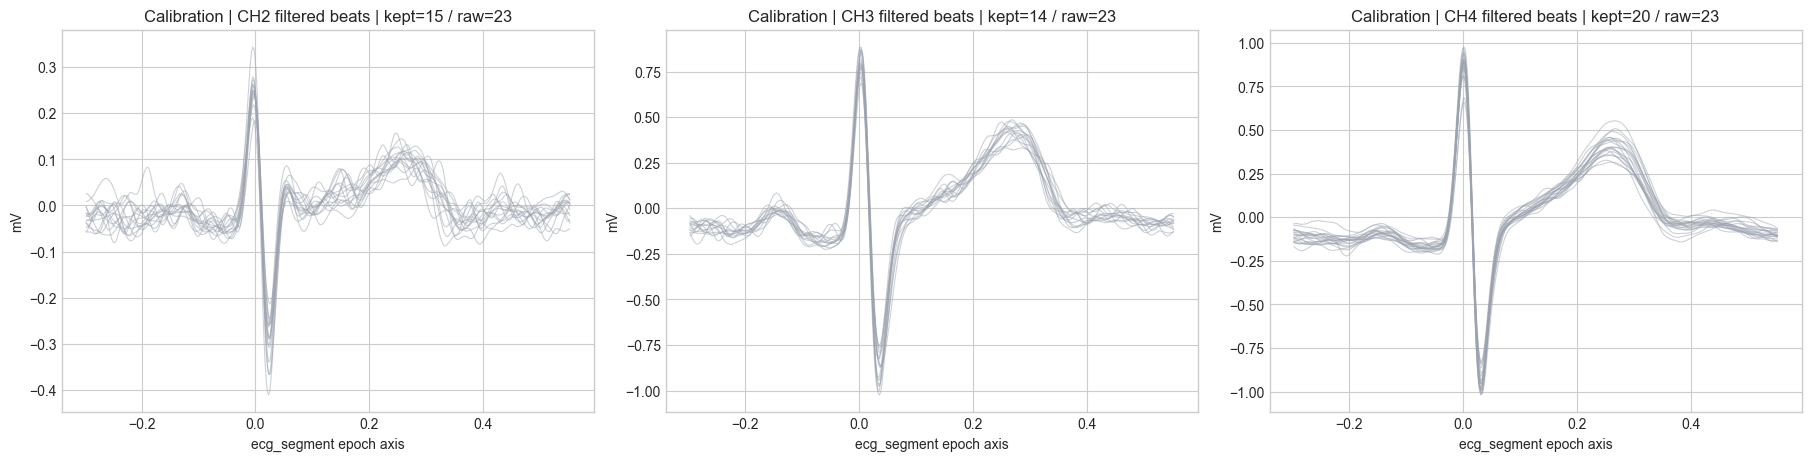

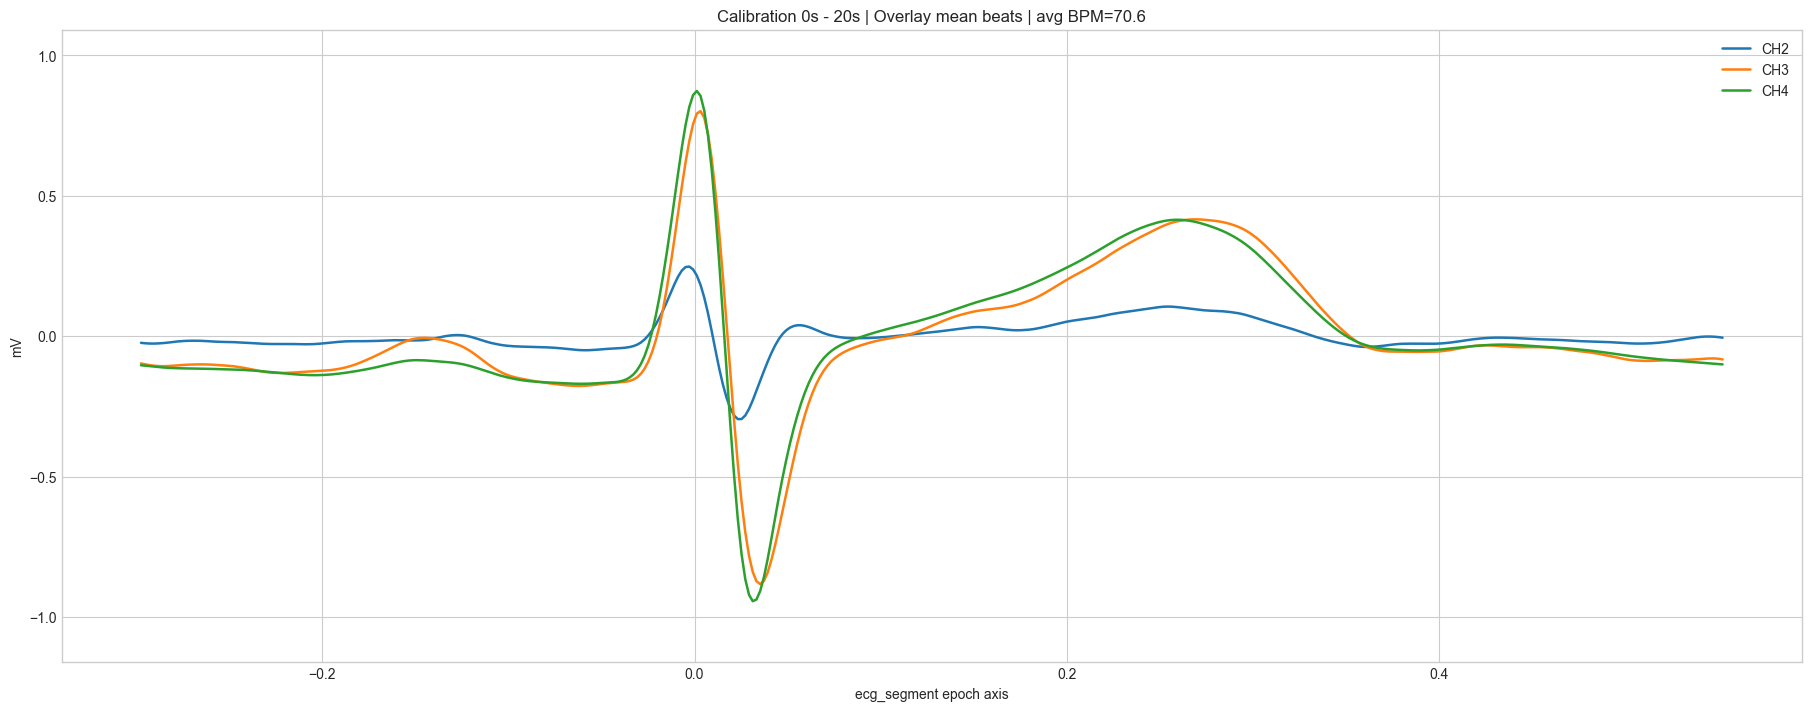

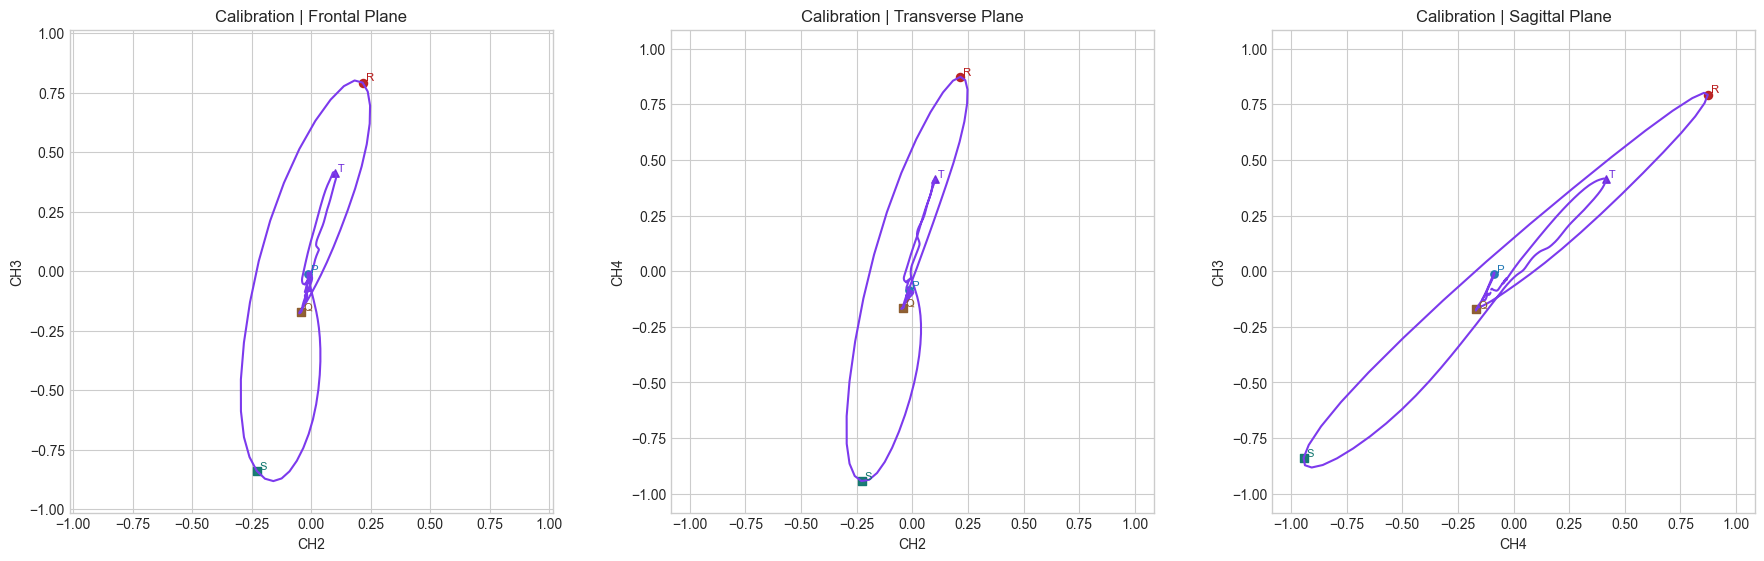

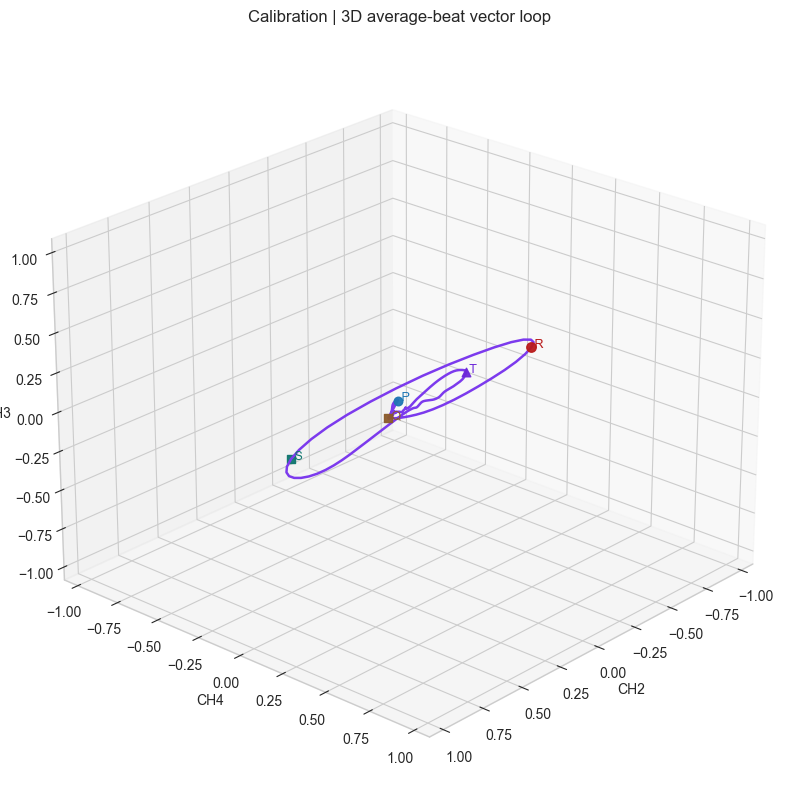

In [7]:
CALIBRATION_FILE = Path("calibration_05Apr26_0432H.bin")
CALIBRATION_START = 0
CALIBRATION_END = 10_000

calibration_payload = CALIBRATION_FILE.read_bytes()
calibration_channels = decode_ads1298_packets(calibration_payload)
calibration_total_samples = len(calibration_channels["CH2"])
calibration_end = min(calibration_total_samples, CALIBRATION_END)

print(f"Loaded {CALIBRATION_FILE.name} | total samples per channel: {calibration_total_samples:,}")
print(f"Calibration window: start_sample={CALIBRATION_START:,}, end_sample={calibration_end:,}, sample_count={max(0, calibration_end - CALIBRATION_START):,}")

calibration_raw_window = {
    channel_label: calibration_channels[channel_label][CALIBRATION_START:calibration_end]
    for channel_label in CHANNEL_LABELS
}

calibration_processed_anchor_signals, calibration_processed_anchor_info = nk.ecg_process(
    calibration_raw_window[ANCHOR_CHANNEL],
    sampling_rate=SAMPLING_RATE,
)
calibration_anchor_rpeaks = np.asarray(calibration_processed_anchor_info.get("ECG_R_Peaks", np.array([], dtype=int)), dtype=int)
calibration_average_bpm = float(np.nanmean(np.asarray(calibration_processed_anchor_signals["ECG_Rate"], dtype=float)))

calibration_anchor_marker_positions = {
    "P": sanitize_marker_positions(calibration_processed_anchor_info.get("ECG_P_Peaks", [])),
    "Q": sanitize_marker_positions(calibration_processed_anchor_info.get("ECG_Q_Peaks", [])),
    "R": calibration_anchor_rpeaks,
    "S": sanitize_marker_positions(calibration_processed_anchor_info.get("ECG_S_Peaks", [])),
    "T": sanitize_marker_positions(calibration_processed_anchor_info.get("ECG_T_Peaks", [])),
}

calibration_anchor_marker_indices = {}
for marker_label, marker_positions in calibration_anchor_marker_positions.items():
    marker_signal = build_marker_signal(len(calibration_raw_window[ANCHOR_CHANNEL]), marker_positions)
    marker_segments = nk.ecg_segment(
        marker_signal,
        rpeaks=calibration_anchor_rpeaks,
        sampling_rate=SAMPLING_RATE,
        show=False,
    )
    marker_epoch_axis, marker_matrix = segmented_beats_to_matrix(marker_segments)
    if marker_matrix.size == 0:
        calibration_anchor_marker_indices[marker_label] = None
    else:
        marker_profile = np.nanmean(marker_matrix, axis=0)
        calibration_anchor_marker_indices[marker_label] = int(np.nanargmax(marker_profile)) if np.nanmax(marker_profile) > 0 else None

calibration_cleaned_window = {
    "CH2": nk.ecg_clean(calibration_raw_window["CH2"], sampling_rate=SAMPLING_RATE, method="neurokit"),
    "CH3": nk.ecg_clean(calibration_raw_window["CH3"], sampling_rate=SAMPLING_RATE, method="neurokit"),
    "CH4": np.asarray(calibration_processed_anchor_signals["ECG_Clean"], dtype=float),
}

calibration_average_beats = {
    "start_sample": CALIBRATION_START,
    "end_sample": calibration_end,
    "average_bpm": calibration_average_bpm,
    "channels": {},
}

for channel_label in CHANNEL_LABELS:
    segments = nk.ecg_segment(
        calibration_cleaned_window[channel_label],
        rpeaks=calibration_anchor_rpeaks,
        sampling_rate=SAMPLING_RATE,
        show=False,
    )
    epoch_axis, beat_matrix = segmented_beats_to_matrix(segments)
    if beat_matrix.size == 0:
        mean_beat = np.array([], dtype=float)
    else:
        mean_beat = np.nanmean(beat_matrix, axis=0)

    filtered_beat_matrix, keep_mask = reject_outlier_beats(beat_matrix, z_threshold=BEAT_OUTLIER_Z_THRESHOLD)
    if filtered_beat_matrix.size == 0:
        mean_beat = np.array([], dtype=float)
    else:
        mean_beat = np.nanmean(filtered_beat_matrix, axis=0)

    calibration_average_beats["channels"][channel_label] = {
        "epoch_axis": epoch_axis,
        "beat_matrix": beat_matrix,
        "filtered_beat_matrix": filtered_beat_matrix,
        "keep_mask": keep_mask,
        "mean_beat": mean_beat,
        "n_beats": int(filtered_beat_matrix.shape[0]) if filtered_beat_matrix.ndim == 2 else 0,
        "n_beats_raw": int(beat_matrix.shape[0]) if beat_matrix.ndim == 2 else 0,
    }

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True, constrained_layout=True)
colors = {"CH2": "#1f77b4", "CH3": "#ff7f0e", "CH4": "#2ca02c"}
for axis, channel_label in zip(axes, CHANNEL_LABELS):
    channel_data = calibration_average_beats["channels"][channel_label]
    epoch_axis = channel_data["epoch_axis"]
    beat_matrix = channel_data["filtered_beat_matrix"]
    if beat_matrix.size:
        for beat in beat_matrix:
            axis.plot(epoch_axis, beat, color="#9ca3af", linewidth=0.8, alpha=0.5)
    axis.set_title(f"Calibration | {channel_label} filtered beats | kept={channel_data['n_beats']} / raw={channel_data['n_beats_raw']}")
    axis.set_xlabel("ecg_segment epoch axis")
    axis.set_ylabel("mV")
plt.show()

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
all_values = []
for channel_label in CHANNEL_LABELS:
    channel_data = calibration_average_beats["channels"][channel_label]
    epoch_axis = channel_data["epoch_axis"]
    mean_beat = channel_data["mean_beat"]
    if len(mean_beat):
        ax.plot(
            epoch_axis,
            mean_beat,
            color=colors[channel_label],
            linewidth=1.8,
            label=channel_label,
        )
        finite_values = mean_beat[np.isfinite(mean_beat)]
        if len(finite_values):
            all_values.append(finite_values)

if all_values:
    combined = np.concatenate(all_values)
    y_min = float(np.min(combined))
    y_max = float(np.max(combined))
    y_range = max(y_max - y_min, 1e-6)
    padding = 0.12 * y_range
    ax.set_ylim(y_min - padding, y_max + padding)

ax.set_title(f"Calibration 0s - 20s | Overlay mean beats | avg BPM={calibration_average_beats['average_bpm']:.1f}")
ax.set_xlabel("ecg_segment epoch axis")
ax.set_ylabel("mV")
ax.legend(loc="upper right")
plt.show()



VECTOR_LINE_COLOR = "#7c3aed"
VECTOR_AXIS_PADDING_RATIO = 0.15
CALIBRATION_VECTOR_PLANES = [
    ("Frontal Plane", "CH2", "CH3"),
    ("Transverse Plane", "CH2", "CH4"),
    ("Sagittal Plane", "CH4", "CH3"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
for ax, (plane_name, x_channel, y_channel) in zip(axes, CALIBRATION_VECTOR_PLANES):
    x_signal = np.asarray(calibration_average_beats["channels"][x_channel]["mean_beat"], dtype=float)
    y_signal = np.asarray(calibration_average_beats["channels"][y_channel]["mean_beat"], dtype=float)

    finite_mask = np.isfinite(x_signal) & np.isfinite(y_signal)
    x_signal = x_signal[finite_mask]
    y_signal = y_signal[finite_mask]

    if len(x_signal) and len(y_signal):
        ax.plot(x_signal, y_signal, color=VECTOR_LINE_COLOR, linewidth=1.5)

        for marker_label, marker_index in calibration_anchor_marker_indices.items():
            if marker_index is None or marker_index >= len(x_signal) or marker_index >= len(y_signal):
                continue
            if not np.isfinite(x_signal[marker_index]) or not np.isfinite(y_signal[marker_index]):
                continue
            style = {"P": {"color": "#1f77b4", "marker": "o"}, "Q": {"color": "#8b5a2b", "marker": "s"}, "R": {"color": "#b91c1c", "marker": "o"}, "S": {"color": "#0f766e", "marker": "s"}, "T": {"color": "#6d28d9", "marker": "^"}}[marker_label]
            ax.scatter(
                x_signal[marker_index],
                y_signal[marker_index],
                s=28 if marker_label != "R" else 34,
                color=style["color"],
                marker=style["marker"],
                alpha=0.95,
            )
            ax.text(
                x_signal[marker_index],
                y_signal[marker_index],
                f" {marker_label}",
                fontsize=8,
                color=style["color"],
                va="bottom",
            )

        max_abs = max(
            float(np.max(np.abs(x_signal))),
            float(np.max(np.abs(y_signal))),
            1e-6,
        )
        axis_limit = max_abs * (1.0 + VECTOR_AXIS_PADDING_RATIO)
        ax.set_xlim(-axis_limit, axis_limit)
        ax.set_ylim(-axis_limit, axis_limit)

    ax.set_title(f"Calibration | {plane_name}")
    ax.set_xlabel(x_channel)
    ax.set_ylabel(y_channel)
    ax.set_aspect("equal", adjustable="box")
    ax.margins(x=0.02, y=0.02)

plt.show()




from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

x_signal = np.asarray(calibration_average_beats["channels"]["CH2"]["mean_beat"], dtype=float)
y_signal = np.asarray(calibration_average_beats["channels"]["CH4"]["mean_beat"], dtype=float)
z_signal = np.asarray(calibration_average_beats["channels"]["CH3"]["mean_beat"], dtype=float)
finite_mask = np.isfinite(x_signal) & np.isfinite(y_signal) & np.isfinite(z_signal)

x_plot = x_signal[finite_mask]
y_plot = y_signal[finite_mask]
z_plot = z_signal[finite_mask]

if len(x_plot) and len(y_plot) and len(z_plot):
    ax.plot(x_plot, y_plot, z_plot, color=VECTOR_LINE_COLOR, linewidth=1.8)

    for marker_label, marker_index in calibration_anchor_marker_indices.items():
        if marker_index is None or marker_index >= len(x_signal) or marker_index >= len(y_signal) or marker_index >= len(z_signal):
            continue
        if not (np.isfinite(x_signal[marker_index]) and np.isfinite(y_signal[marker_index]) and np.isfinite(z_signal[marker_index])):
            continue
        style = {"P": {"color": "#1f77b4", "marker": "o"}, "Q": {"color": "#8b5a2b", "marker": "s"}, "R": {"color": "#b91c1c", "marker": "o"}, "S": {"color": "#0f766e", "marker": "s"}, "T": {"color": "#6d28d9", "marker": "^"}}[marker_label]
        ax.scatter(
            x_signal[marker_index],
            y_signal[marker_index],
            z_signal[marker_index],
            s=38 if marker_label != "R" else 46,
            color=style["color"],
            marker=style["marker"],
            alpha=0.95,
        )
        ax.text(
            x_signal[marker_index],
            y_signal[marker_index],
            z_signal[marker_index],
            f" {marker_label}",
            color=style["color"],
            fontsize=9,
        )

    max_abs = max(
        float(np.max(np.abs(x_plot))),
        float(np.max(np.abs(y_plot))),
        float(np.max(np.abs(z_plot))),
        1e-6,
    )
    axis_limit = max_abs * (1.0 + VECTOR_AXIS_PADDING_RATIO)
    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)
    ax.set_zlim(-axis_limit, axis_limit)

ax.set_title("Calibration | 3D average-beat vector loop")
ax.set_xlabel("CH2")
ax.set_ylabel("CH4")
ax.set_zlabel("CH3")
ax.view_init(elev=24, azim=42)
plt.show()



In [8]:
def _finite_points(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> np.ndarray:
    points = np.column_stack([np.asarray(x, dtype=float), np.asarray(y, dtype=float), np.asarray(z, dtype=float)])
    return points[np.all(np.isfinite(points), axis=1)]


def _interval_bounds(marker_indices: dict, start_label: str, end_label: str, length: int):
    start = marker_indices.get(start_label)
    end = marker_indices.get(end_label)
    if start is None or end is None:
        return None
    start = int(start)
    end = int(end)
    if start < 0 or end < 0 or start >= length or end >= length:
        return None
    if end <= start:
        return None
    return start, end


def mean_vector_over_interval(ch2: np.ndarray, ch4: np.ndarray, ch3: np.ndarray, start: int, end: int) -> np.ndarray:
    points = _finite_points(ch2[start:end + 1], ch4[start:end + 1], ch3[start:end + 1])
    if len(points) == 0:
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    return np.nanmean(points, axis=0)


def compute_spatial_qrs_t_angle(ch2: np.ndarray, ch4: np.ndarray, ch3: np.ndarray, marker_indices: dict) -> float:
    length = len(ch2)
    baseline_bounds = _interval_bounds(marker_indices, "P", "Q", length)
    qrs_bounds = _interval_bounds(marker_indices, "Q", "S", length)
    t_bounds = _interval_bounds(marker_indices, "S", "T", length)
    if baseline_bounds is None or qrs_bounds is None or t_bounds is None:
        return float("nan")

    baseline = mean_vector_over_interval(ch2, ch4, ch3, baseline_bounds[0], baseline_bounds[1])
    qrs_vector = mean_vector_over_interval(ch2, ch4, ch3, qrs_bounds[0], qrs_bounds[1]) - baseline
    t_vector = mean_vector_over_interval(ch2, ch4, ch3, t_bounds[0], t_bounds[1]) - baseline

    qrs_norm = np.linalg.norm(qrs_vector)
    t_norm = np.linalg.norm(t_vector)
    if not np.isfinite(qrs_norm) or not np.isfinite(t_norm) or qrs_norm == 0 or t_norm == 0:
        return float("nan")

    cos_theta = np.dot(qrs_vector, t_vector) / (qrs_norm * t_norm)
    cos_theta = float(np.clip(cos_theta, -1.0, 1.0))
    return float(np.degrees(np.arccos(cos_theta)))


def compute_st_injury_vector(ch2: np.ndarray, ch4: np.ndarray, ch3: np.ndarray, marker_indices: dict, st_offset_start: int = 10, st_offset_end: int = 30) -> dict:
    length = len(ch2)
    baseline_bounds = _interval_bounds(marker_indices, "P", "Q", length)
    s_index = marker_indices.get("S")
    t_index = marker_indices.get("T")
    if baseline_bounds is None or s_index is None or t_index is None:
        return {"vector": np.array([np.nan, np.nan, np.nan], dtype=float), "magnitude": float("nan"), "azimuth_deg": float("nan"), "elevation_deg": float("nan")}

    s_index = int(s_index)
    t_index = int(t_index)
    st_start = s_index + st_offset_start
    st_end = min(s_index + st_offset_end, t_index)
    if st_end <= st_start or st_start >= length:
        return {"vector": np.array([np.nan, np.nan, np.nan], dtype=float), "magnitude": float("nan"), "azimuth_deg": float("nan"), "elevation_deg": float("nan")}

    baseline = mean_vector_over_interval(ch2, ch4, ch3, baseline_bounds[0], baseline_bounds[1])
    st_vector_point = mean_vector_over_interval(ch2, ch4, ch3, st_start, st_end)
    injury_vector = st_vector_point - baseline
    magnitude = float(np.linalg.norm(injury_vector))
    azimuth_deg = float(np.degrees(np.arctan2(injury_vector[1], injury_vector[0]))) if np.isfinite(magnitude) and magnitude > 0 else float("nan")
    horizontal_norm = float(np.linalg.norm(injury_vector[:2]))
    elevation_deg = float(np.degrees(np.arctan2(injury_vector[2], horizontal_norm))) if np.isfinite(magnitude) and magnitude > 0 else float("nan")

    return {
        "vector": injury_vector,
        "magnitude": magnitude,
        "azimuth_deg": azimuth_deg,
        "elevation_deg": elevation_deg,
    }


def compute_loop_complexity(ch2: np.ndarray, ch4: np.ndarray, ch3: np.ndarray) -> float:
    points = _finite_points(ch2, ch4, ch3)
    if len(points) < 2:
        return float("nan")

    path_length = float(np.sum(np.linalg.norm(np.diff(points, axis=0), axis=1)))
    pairwise = points[:, None, :] - points[None, :, :]
    diameter = float(np.max(np.linalg.norm(pairwise, axis=2)))
    if diameter == 0:
        return float("nan")
    return path_length / diameter


calibration_mean_ch2 = np.asarray(calibration_average_beats["channels"]["CH2"]["mean_beat"], dtype=float)
calibration_mean_ch4 = np.asarray(calibration_average_beats["channels"]["CH4"]["mean_beat"], dtype=float)
calibration_mean_ch3 = np.asarray(calibration_average_beats["channels"]["CH3"]["mean_beat"], dtype=float)
calibration_markers = calibration_anchor_marker_indices

spatial_qrs_t_angle_deg = compute_spatial_qrs_t_angle(
    calibration_mean_ch2,
    calibration_mean_ch4,
    calibration_mean_ch3,
    calibration_markers,
)

st_injury = compute_st_injury_vector(
    calibration_mean_ch2,
    calibration_mean_ch4,
    calibration_mean_ch3,
    calibration_markers,
)

loop_complexity = compute_loop_complexity(
    calibration_mean_ch2,
    calibration_mean_ch4,
    calibration_mean_ch3,
)

metric_columns = np.array([
    "Spatial QRS-T Angle",
    "ST Injury Vector",
    "ST Injury Vector Magnitude",
    "ST Injury Vector Azimuth (deg)",
    "ST Injury Vector Elevation (deg)",
    "Loop Complexity (total_arc_length/max_pairwise_3d_distance)",
], dtype=object)

metric_row = np.array([
    f"{spatial_qrs_t_angle_deg:.3f}",
    f"[{st_injury['vector'][0]:.6f}, {st_injury['vector'][1]:.6f}, {st_injury['vector'][2]:.6f}]",
    f"{st_injury['magnitude']:.6f}",
    f"{st_injury['azimuth_deg']:.3f}",
    f"{st_injury['elevation_deg']:.3f}",
    f"{loop_complexity:.6f}",
], dtype=object)

calibration_vcg_metrics_table = np.vstack([metric_columns, metric_row])
calibration_vcg_metrics_table

array([['Spatial QRS-T Angle', 'ST Injury Vector',
        'ST Injury Vector Magnitude', 'ST Injury Vector Azimuth (deg)',
        'ST Injury Vector Elevation (deg)',
        'Loop Complexity (total_arc_length/max_pairwise_3d_distance)'],
       ['12.576', '[0.032566, 0.013980, -0.077132]', '0.084884',
        '23.233', '-65.323', '2.954774']], dtype=object)

In [9]:
def compute_average_bpm_from_rpeaks(rpeaks: np.ndarray, sampling_rate: int = 500) -> float:
    rpeaks = np.asarray(rpeaks, dtype=int)
    if len(rpeaks) < 2:
        return float("nan")
    rr_intervals = np.diff(rpeaks)
    rr_intervals = rr_intervals[rr_intervals > 0]
    if len(rr_intervals) == 0:
        return float("nan")
    return float(60.0 * sampling_rate / np.mean(rr_intervals))


def compute_representative_marker_indices(
    anchor_rpeaks: np.ndarray,
    marker_positions: dict,
    epoch_axis: np.ndarray,
    beat_length: int,
) -> dict:
    if len(epoch_axis) == 0 or beat_length <= 0:
        return {label: None for label in ["P", "Q", "R", "S", "T"]}

    center_idx = int(np.argmin(np.abs(epoch_axis)))
    representative_indices = {"R": center_idx}
    anchor_rpeaks = np.asarray(anchor_rpeaks, dtype=int)

    for marker_label in ["P", "Q", "S", "T"]:
        positions = np.asarray(marker_positions.get(marker_label, np.array([], dtype=int)), dtype=int)
        local_indices = []

        for beat_idx, rpeak in enumerate(anchor_rpeaks):
            prev_r = anchor_rpeaks[beat_idx - 1] if beat_idx > 0 else -10**12
            next_r = anchor_rpeaks[beat_idx + 1] if beat_idx < len(anchor_rpeaks) - 1 else 10**12

            if marker_label in ["P", "Q"]:
                candidates = positions[(positions > prev_r) & (positions < rpeak)]
                if len(candidates) == 0:
                    continue
                marker_pos = int(candidates[-1])
            else:
                candidates = positions[(positions > rpeak) & (positions < next_r)]
                if len(candidates) == 0:
                    continue
                marker_pos = int(candidates[0])

            local_idx = center_idx + (marker_pos - rpeak)
            if 0 <= local_idx < beat_length:
                local_indices.append(local_idx)

        representative_indices[marker_label] = int(round(np.median(local_indices))) if local_indices else None

    return representative_indices


def compute_average_beats_for_window(raw_window: Dict[str, np.ndarray], sampling_rate: int = 500, anchor_channel: str = "CH4") -> dict:
    cleaned_anchor = nk.ecg_clean(raw_window[anchor_channel], sampling_rate=sampling_rate, method="neurokit")
    _, peak_info = nk.ecg_peaks(
        cleaned_anchor,
        sampling_rate=sampling_rate,
        method="neurokit",
        correct_artifacts=False,
    )
    anchor_rpeaks = sanitize_marker_positions(peak_info.get("ECG_R_Peaks", []))
    average_bpm = compute_average_bpm_from_rpeaks(anchor_rpeaks, sampling_rate=sampling_rate)

    cleaned_window = {
        "CH2": nk.ecg_clean(raw_window["CH2"], sampling_rate=sampling_rate, method="neurokit"),
        "CH3": nk.ecg_clean(raw_window["CH3"], sampling_rate=sampling_rate, method="neurokit"),
        "CH4": np.asarray(cleaned_anchor, dtype=float),
    }

    if len(anchor_rpeaks) >= 2:
        delineate_result = nk.ecg_delineate(
            cleaned_window[anchor_channel],
            anchor_rpeaks,
            sampling_rate=sampling_rate,
            method="dwt",
        )
        if isinstance(delineate_result, tuple):
            _, delineate_info = delineate_result
        else:
            delineate_info = delineate_result
    else:
        delineate_info = {}

    anchor_marker_positions = {
        "P": sanitize_marker_positions(delineate_info.get("ECG_P_Peaks", [])),
        "Q": sanitize_marker_positions(delineate_info.get("ECG_Q_Peaks", [])),
        "R": anchor_rpeaks,
        "S": sanitize_marker_positions(delineate_info.get("ECG_S_Peaks", [])),
        "T": sanitize_marker_positions(delineate_info.get("ECG_T_Peaks", [])),
    }

    channels_result = {}
    for channel_label in CHANNEL_LABELS:
        segments = nk.ecg_segment(
            cleaned_window[channel_label],
            rpeaks=anchor_rpeaks,
            sampling_rate=sampling_rate,
            show=False,
        )
        epoch_axis, beat_matrix = segmented_beats_to_matrix(segments)
        filtered_beat_matrix, keep_mask = reject_outlier_beats(beat_matrix, z_threshold=BEAT_OUTLIER_Z_THRESHOLD)
        if filtered_beat_matrix.size == 0:
            mean_beat = np.array([], dtype=float)
        else:
            mean_beat = np.nanmean(filtered_beat_matrix, axis=0)

        channels_result[channel_label] = {
            "segments": segments,
            "epoch_axis": epoch_axis,
            "beat_matrix": beat_matrix,
            "filtered_beat_matrix": filtered_beat_matrix,
            "keep_mask": keep_mask,
            "mean_beat": mean_beat,
            "n_beats": int(filtered_beat_matrix.shape[0]) if filtered_beat_matrix.ndim == 2 else 0,
            "n_beats_raw": int(beat_matrix.shape[0]) if beat_matrix.ndim == 2 else 0,
        }

    anchor_epoch_axis = channels_result[anchor_channel]["epoch_axis"]
    beat_length = len(channels_result[anchor_channel]["mean_beat"])
    anchor_marker_indices = compute_representative_marker_indices(
        anchor_rpeaks,
        anchor_marker_positions,
        anchor_epoch_axis,
        beat_length,
    )

    return {
        "anchor_channel": anchor_channel,
        "anchor_rpeaks": anchor_rpeaks,
        "average_bpm": average_bpm,
        "cleaned_window": cleaned_window,
        "marker_indices": anchor_marker_indices,
        "channels": channels_result,
    }


def compute_vcg_metrics(mean_ch2: np.ndarray, mean_ch4: np.ndarray, mean_ch3: np.ndarray, marker_indices: dict) -> dict:
    spatial_qrs_t_angle = compute_spatial_qrs_t_angle(mean_ch2, mean_ch4, mean_ch3, marker_indices)
    st_injury = compute_st_injury_vector(mean_ch2, mean_ch4, mean_ch3, marker_indices)
    loop_complexity = compute_loop_complexity(mean_ch2, mean_ch4, mean_ch3)

    return {
        "spatial_qrs_t_angle": spatial_qrs_t_angle,
        "st_injury_vector": st_injury["vector"],
        "st_injury_vector_magnitude": st_injury["magnitude"],
        "st_injury_vector_azimuth_deg": st_injury["azimuth_deg"],
        "st_injury_vector_elevation_deg": st_injury["elevation_deg"],
        "loop_complexity": loop_complexity,
    }


def flatten_metric_row(window_index: int, start_sample: int, end_sample: int, sampling_rate: int, average_bpm: float, metrics: dict, calibration_metrics: dict | None = None) -> dict:
    row = {
        "window_index": window_index,
        "start_sample": start_sample,
        "end_sample": end_sample,
        "start_sec": start_sample / sampling_rate,
        "end_sec": end_sample / sampling_rate,
        "average_bpm": average_bpm,
        "spatial_qrs_t_angle": metrics["spatial_qrs_t_angle"],
        "st_injury_vector_x": metrics["st_injury_vector"][0],
        "st_injury_vector_y": metrics["st_injury_vector"][1],
        "st_injury_vector_z": metrics["st_injury_vector"][2],
        "st_injury_vector_magnitude": metrics["st_injury_vector_magnitude"],
        "st_injury_vector_azimuth_deg": metrics["st_injury_vector_azimuth_deg"],
        "st_injury_vector_elevation_deg": metrics["st_injury_vector_elevation_deg"],
        "loop_complexity": metrics["loop_complexity"],
    }

    if calibration_metrics is not None:
        row.update(
            {
                "delta_spatial_qrs_t_angle": metrics["spatial_qrs_t_angle"] - calibration_metrics["spatial_qrs_t_angle"],
                "delta_st_injury_vector_x": metrics["st_injury_vector"][0] - calibration_metrics["st_injury_vector"][0],
                "delta_st_injury_vector_y": metrics["st_injury_vector"][1] - calibration_metrics["st_injury_vector"][1],
                "delta_st_injury_vector_z": metrics["st_injury_vector"][2] - calibration_metrics["st_injury_vector"][2],
                "delta_st_injury_vector_magnitude": metrics["st_injury_vector_magnitude"] - calibration_metrics["st_injury_vector_magnitude"],
                "delta_st_injury_vector_azimuth_deg": metrics["st_injury_vector_azimuth_deg"] - calibration_metrics["st_injury_vector_azimuth_deg"],
                "delta_st_injury_vector_elevation_deg": metrics["st_injury_vector_elevation_deg"] - calibration_metrics["st_injury_vector_elevation_deg"],
                "delta_loop_complexity": metrics["loop_complexity"] - calibration_metrics["loop_complexity"],
            }
        )

    return row

In [10]:
calibration_payload = CALIBRATION_FILE.read_bytes()
calibration_channels = decode_ads1298_packets(calibration_payload)
calibration_end = min(len(calibration_channels["CH2"]), 10_000)

calibration_raw_window = {
    channel_label: calibration_channels[channel_label][0:calibration_end]
    for channel_label in CHANNEL_LABELS
}

calibration_result = compute_average_beats_for_window(
    calibration_raw_window,
    sampling_rate=SAMPLING_RATE,
    anchor_channel=ANCHOR_CHANNEL,
)

calibration_metrics = compute_vcg_metrics(
    calibration_result["channels"]["CH2"]["mean_beat"],
    calibration_result["channels"]["CH4"]["mean_beat"],
    calibration_result["channels"]["CH3"]["mean_beat"],
    calibration_result["marker_indices"],
)

calibration_baseline = {
    "source": "calibration",
    "start_sample": 0,
    "end_sample": calibration_end,
    "start_sec": 0.0,
    "end_sec": calibration_end / SAMPLING_RATE,
    "average_bpm": calibration_result["average_bpm"],
    "mean_beats": {
        "CH2": calibration_result["channels"]["CH2"]["mean_beat"],
        "CH3": calibration_result["channels"]["CH3"]["mean_beat"],
        "CH4": calibration_result["channels"]["CH4"]["mean_beat"],
    },
    "marker_indices": calibration_result["marker_indices"],
    "metrics": calibration_metrics,
}

print("Calibration baseline ready")
print(f"source: {calibration_baseline['source']}")
print(f"window: {calibration_baseline['start_sec']:.1f}s - {calibration_baseline['end_sec']:.1f}s")
print(f"average_bpm: {calibration_baseline['average_bpm']:.3f}")
print("marker_indices:")
for marker_label, marker_index in calibration_baseline["marker_indices"].items():
    print(f"  {marker_label}: {marker_index}")
print("metrics:")
for metric_name, metric_value in calibration_baseline["metrics"].items():
    print(f"  {metric_name}: {metric_value}")



Calibration baseline ready
source: calibration
window: 0.0s - 20.0s
average_bpm: 70.611
marker_indices:
  R: 148
  P: 73
  Q: 118
  S: 163
  T: 278
metrics:
  spatial_qrs_t_angle: 11.868165699481297
  st_injury_vector: [ 0.03746307 -0.00038132 -0.0892131 ]
  st_injury_vector_magnitude: 0.09676054825876466
  st_injury_vector_azimuth_deg: -0.5831676638748079
  st_injury_vector_elevation_deg: -67.2200479422621
  loop_complexity: 2.954774150927859


In [11]:
SESSION_ANALYSIS_FILE = RAW_FILE
MAX_SESSION_WINDOWS = None  # Set to None to analyse the full session.

session_payload = SESSION_ANALYSIS_FILE.read_bytes()
session_channels = decode_ads1298_packets(session_payload)
session_total_samples = len(session_channels["CH2"])
session_total_windows = session_total_samples // WINDOW_SAMPLES

if MAX_SESSION_WINDOWS is None:
    windows_to_analyse = session_total_windows
else:
    windows_to_analyse = min(int(MAX_SESSION_WINDOWS), session_total_windows)

print(f"Loaded {SESSION_ANALYSIS_FILE.name} | total samples per channel: {session_total_samples:,}")
print(f"20s windows available: {session_total_windows:,}")
print(f"20s windows selected for analysis: {windows_to_analyse:,}")

session_window_results = []

for window_index in range(windows_to_analyse):
    start_sample = window_index * WINDOW_SAMPLES
    end_sample = min(session_total_samples, start_sample + WINDOW_SAMPLES)
    if end_sample <= start_sample:
        continue

    raw_window = {
        channel_label: session_channels[channel_label][start_sample:end_sample]
        for channel_label in CHANNEL_LABELS
    }

    window_result = compute_average_beats_for_window(
        raw_window,
        sampling_rate=SAMPLING_RATE,
        anchor_channel=ANCHOR_CHANNEL,
    )

    window_metrics = compute_vcg_metrics(
        window_result["channels"]["CH2"]["mean_beat"],
        window_result["channels"]["CH4"]["mean_beat"],
        window_result["channels"]["CH3"]["mean_beat"],
        window_result["marker_indices"],
    )

    session_window_results.append(
        {
            "window_index": window_index,
            "start_sample": start_sample,
            "end_sample": end_sample,
            "start_sec": start_sample / SAMPLING_RATE,
            "end_sec": end_sample / SAMPLING_RATE,
            "average_bpm": window_result["average_bpm"],
            "mean_beats": {
                "CH2": window_result["channels"]["CH2"]["mean_beat"],
                "CH3": window_result["channels"]["CH3"]["mean_beat"],
                "CH4": window_result["channels"]["CH4"]["mean_beat"],
            },
            "marker_indices": window_result["marker_indices"],
            "metrics": window_metrics,
        }
    )

    print(
        f"window_index={window_index:>3} | "
        f"time={start_sample / SAMPLING_RATE:>6.1f}s-{end_sample / SAMPLING_RATE:>6.1f}s | "
        f"avg_bpm={window_result['average_bpm']:.2f}"
    )

print(f"\nSession window results ready: {len(session_window_results):,}")




Loaded session_05Apr26_0459H.bin | total samples per channel: 5,083,975
20s windows available: 508
20s windows selected for analysis: 508
window_index=  0 | time=   0.0s-  20.0s | avg_bpm=84.97
window_index=  1 | time=  20.0s-  40.0s | avg_bpm=112.16
window_index=  2 | time=  40.0s-  60.0s | avg_bpm=114.84
window_index=  3 | time=  60.0s-  80.0s | avg_bpm=118.71
window_index=  4 | time=  80.0s- 100.0s | avg_bpm=123.38
window_index=  5 | time= 100.0s- 120.0s | avg_bpm=125.82
window_index=  6 | time= 120.0s- 140.0s | avg_bpm=124.99
window_index=  7 | time= 140.0s- 160.0s | avg_bpm=128.04
window_index=  8 | time= 160.0s- 180.0s | avg_bpm=132.83
window_index=  9 | time= 180.0s- 200.0s | avg_bpm=130.69
window_index= 10 | time= 200.0s- 220.0s | avg_bpm=135.16
window_index= 11 | time= 220.0s- 240.0s | avg_bpm=136.62
window_index= 12 | time= 240.0s- 260.0s | avg_bpm=133.43
window_index= 13 | time= 260.0s- 280.0s | avg_bpm=133.81
window_index= 14 | time= 280.0s- 300.0s | avg_bpm=134.92
window_i

In [12]:
session_window_metrics_with_delta = []
session_metrics_table_rows = []

for window_result in session_window_results:
    flat_row = flatten_metric_row(
        window_index=window_result["window_index"],
        start_sample=window_result["start_sample"],
        end_sample=window_result["end_sample"],
        sampling_rate=SAMPLING_RATE,
        average_bpm=window_result["average_bpm"],
        metrics=window_result["metrics"],
        calibration_metrics=calibration_baseline["metrics"],
    )

    window_with_delta = {
        **window_result,
        "delta_vs_calibration": {
            "spatial_qrs_t_angle": flat_row["delta_spatial_qrs_t_angle"],
            "st_injury_vector": np.array(
                [
                    flat_row["delta_st_injury_vector_x"],
                    flat_row["delta_st_injury_vector_y"],
                    flat_row["delta_st_injury_vector_z"],
                ],
                dtype=float,
            ),
            "st_injury_vector_magnitude": flat_row["delta_st_injury_vector_magnitude"],
            "st_injury_vector_azimuth_deg": flat_row["delta_st_injury_vector_azimuth_deg"],
            "st_injury_vector_elevation_deg": flat_row["delta_st_injury_vector_elevation_deg"],
            "loop_complexity": flat_row["delta_loop_complexity"],
        },
    }

    session_window_metrics_with_delta.append(window_with_delta)
    session_metrics_table_rows.append(flat_row)

print(f"Session windows with delta ready: {len(session_window_metrics_with_delta):,}")
print(f"Flattened metrics rows ready: {len(session_metrics_table_rows):,}")

if session_metrics_table_rows:
    session_metrics_table_columns = np.array(list(session_metrics_table_rows[0].keys()), dtype=object)
    session_metrics_table_values = np.array(
        [[row[column] for column in session_metrics_table_columns] for row in session_metrics_table_rows],
        dtype=object,
    )
    session_metrics_table = np.vstack([session_metrics_table_columns, session_metrics_table_values])
else:
    session_metrics_table = np.empty((0, 0), dtype=object)

session_metrics_table

Session windows with delta ready: 508
Flattened metrics rows ready: 508


array([['window_index', 'start_sample', 'end_sample', ...,
        'delta_st_injury_vector_azimuth_deg',
        'delta_st_injury_vector_elevation_deg', 'delta_loop_complexity'],
       [0, 0, 10000, ..., -63.49261655370977, -9.21624178968348,
        -0.05862143390058572],
       [1, 10000, 20000, ..., -112.84664260571887, 4.2112372546128825,
        -0.24112689748961724],
       ...,
       [505, 5050000, 5060000, ..., -88.7289558042665,
        -1.6425298109444526, 0.11170090803719335],
       [506, 5060000, 5070000, ..., -75.10557430813601,
        -3.1833433521201613, -0.06660076792622993],
       [507, 5070000, 5080000, ..., -86.4180146033063, 9.427642728653474,
        -0.10663202043639375]], shape=(509, 22), dtype=object)

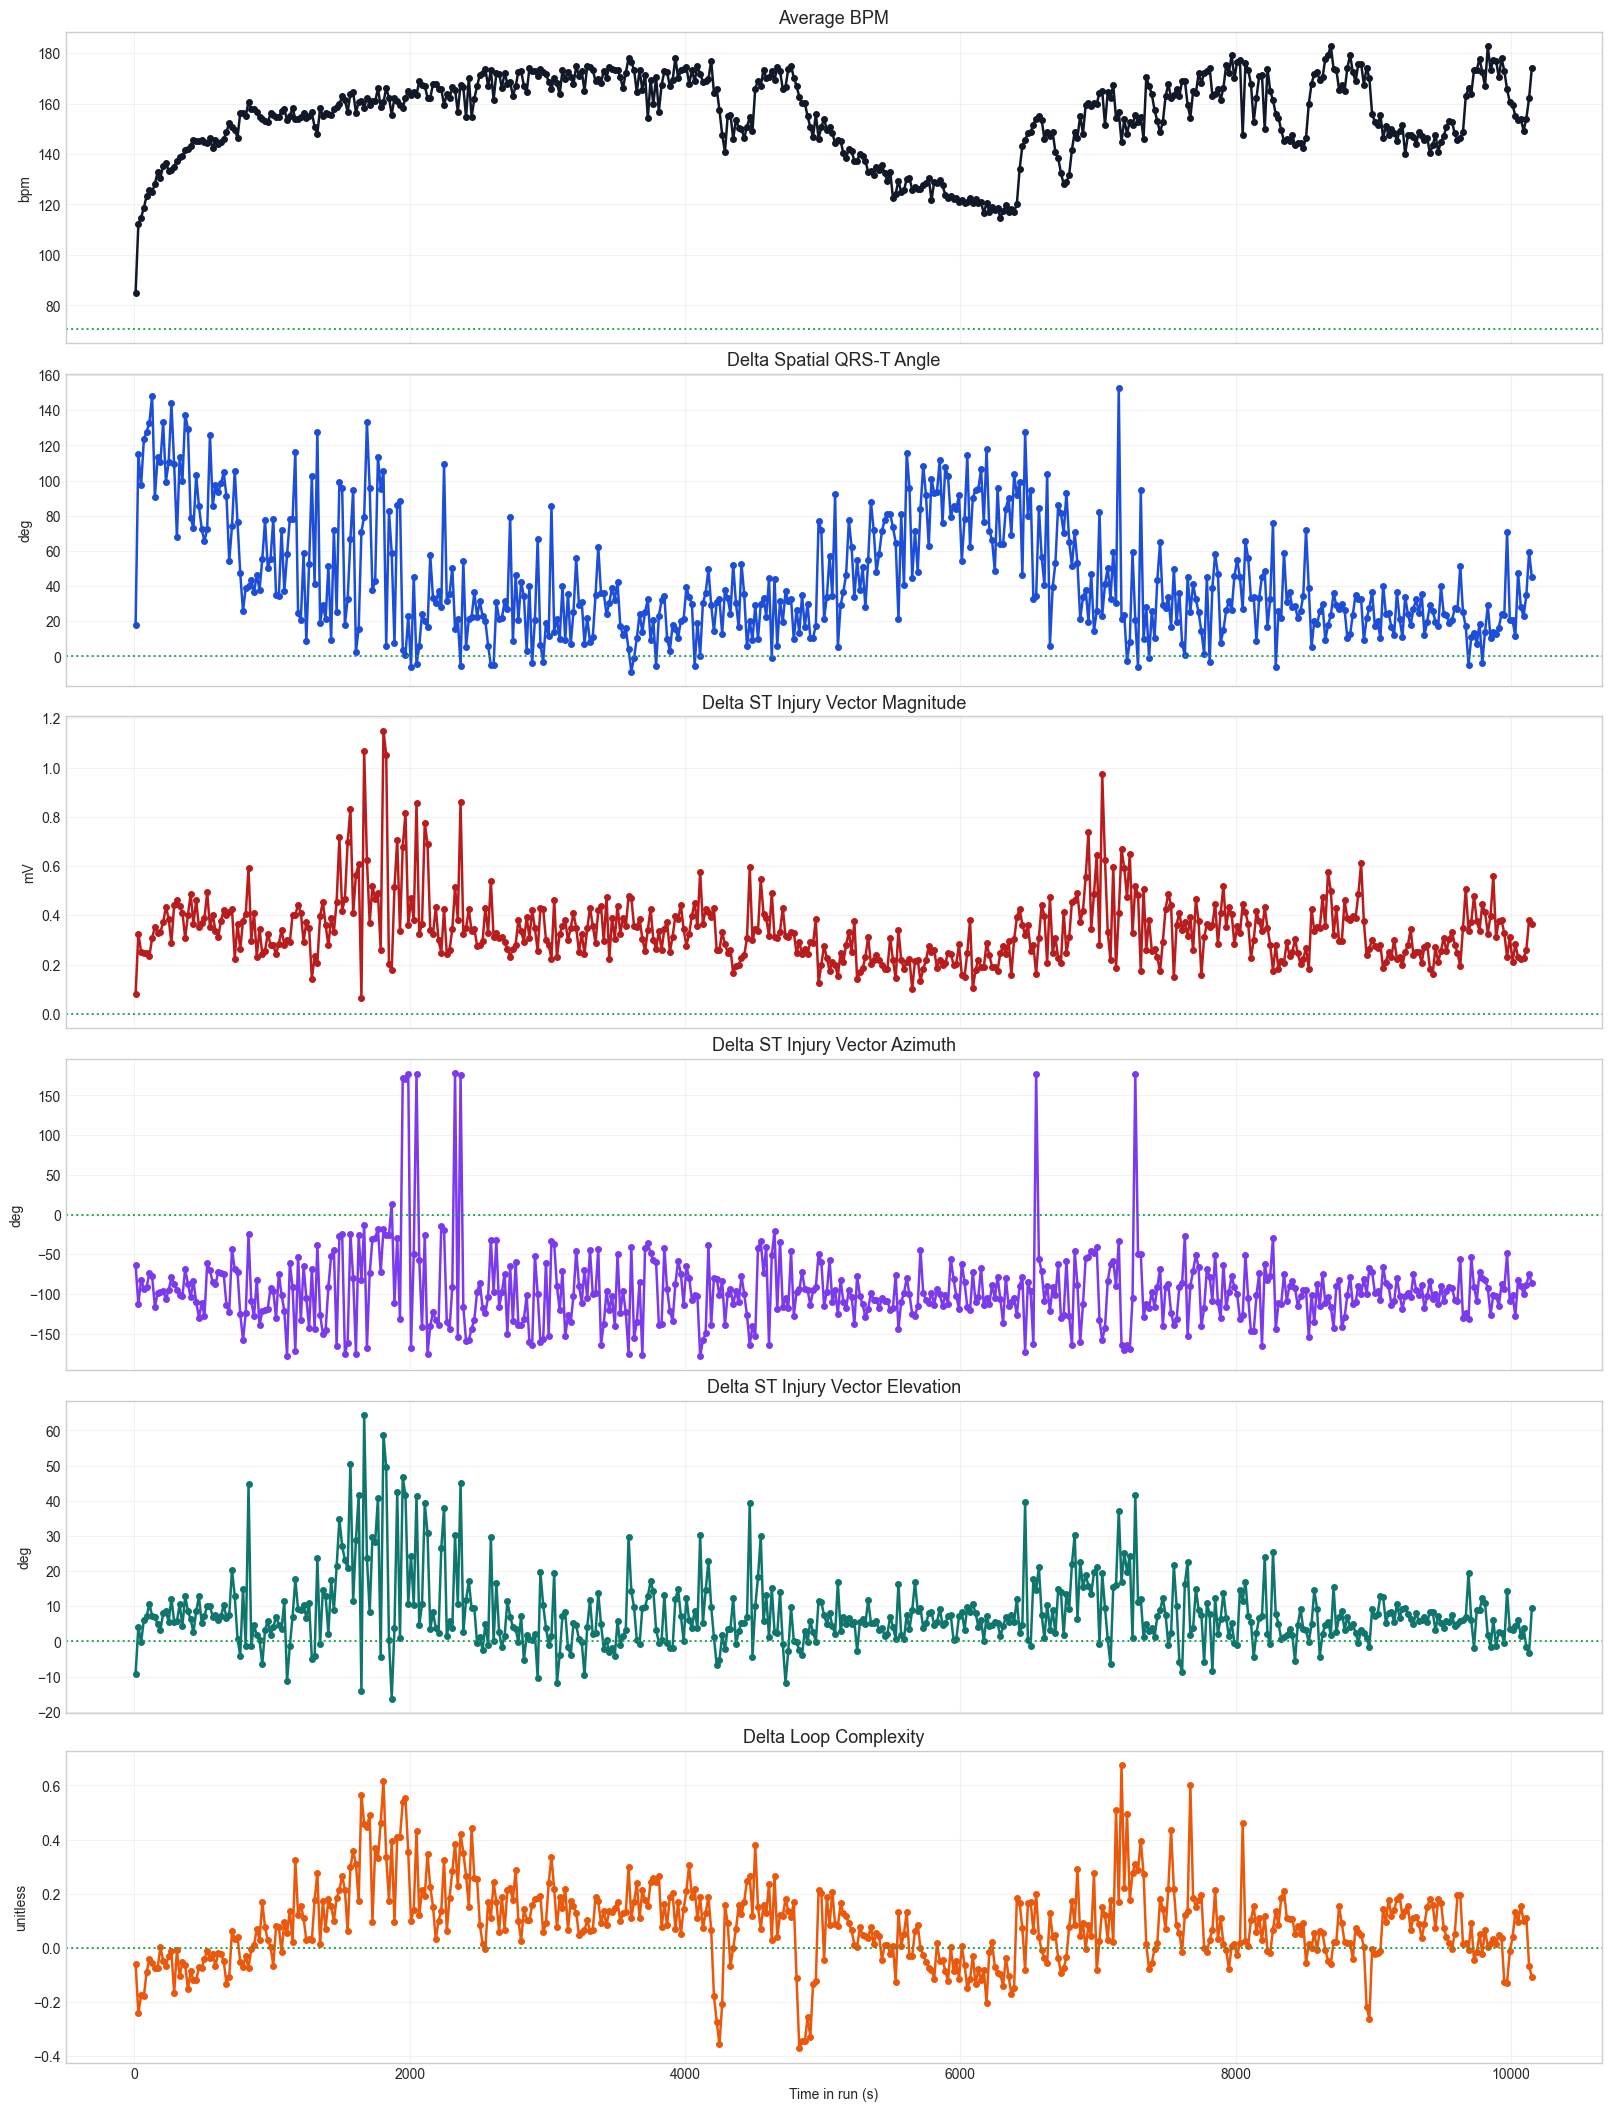

In [13]:
if not session_metrics_table_rows:
    print("No session delta rows available for plotting.")
else:
    plot_specs = [
        ("average_bpm", "Average BPM", "bpm", "#111827", calibration_baseline["average_bpm"]),
        ("delta_spatial_qrs_t_angle", "Delta Spatial QRS-T Angle", "deg", "#1d4ed8", 0.0),
        ("delta_st_injury_vector_magnitude", "Delta ST Injury Vector Magnitude", "mV", "#b91c1c", 0.0),
        ("delta_st_injury_vector_azimuth_deg", "Delta ST Injury Vector Azimuth", "deg", "#7c3aed", 0.0),
        ("delta_st_injury_vector_elevation_deg", "Delta ST Injury Vector Elevation", "deg", "#0f766e", 0.0),
        ("delta_loop_complexity", "Delta Loop Complexity", "unitless", "#ea580c", 0.0),
    ]

    time_centers_sec = np.array([0.5 * (row["start_sec"] + row["end_sec"]) for row in session_metrics_table_rows], dtype=float)

    fig, axes = plt.subplots(len(plot_specs), 1, figsize=(16, 21), sharex=True, constrained_layout=True)
    axes = np.atleast_1d(axes)

    for axis, (key, title, y_label, color, calibration_reference) in zip(axes, plot_specs):
        values = np.array([row[key] for row in session_metrics_table_rows], dtype=float)
        axis.plot(time_centers_sec, values, color=color, linewidth=1.8, marker="o", markersize=4)
        axis.axhline(calibration_reference, color="#16a34a", linewidth=1.4, linestyle=":", alpha=0.95)
        axis.set_title(title, fontsize=13)
        axis.set_ylabel(y_label)
        axis.grid(True, alpha=0.25)

    axes[-1].set_xlabel("Time in run (s)")
    plt.show()





In [19]:
if not session_metrics_table_rows:
    session_metrics_summary_table = np.empty((0, 0), dtype=object)
    print("No session metrics rows available for tabulation.")
    print(session_metrics_summary_table)
else:
    summary_columns = [
        "window_index",
        "start_sec",
        "end_sec",
        "average_bpm",
        "spatial_qrs_t_angle",
        "delta_spatial_qrs_t_angle",
        "st_injury_vector_magnitude",
        "delta_st_injury_vector_magnitude",
        "st_injury_vector_azimuth_deg",
        "delta_st_injury_vector_azimuth_deg",
        "st_injury_vector_elevation_deg",
        "delta_st_injury_vector_elevation_deg",
        "loop_complexity",
        "delta_loop_complexity",
    ]

    def _format_table_value(key: str, value):
        if key == "window_index":
            return str(int(value) + 1)
        if key in {"start_sec", "end_sec"}:
            return f"{float(value):.1f}"
        try:
            return f"{float(value):.4f}"
        except (TypeError, ValueError):
            return str(value)

    session_metrics_summary_table = np.vstack([
        np.array(summary_columns, dtype=object),
        np.array(
            [
                [_format_table_value(column, row[column]) for column in summary_columns]
                for row in session_metrics_table_rows
            ],
            dtype=object,
        ),
    ])

    print(session_metrics_summary_table)  


[['window_index' 'start_sec' 'end_sec' ...
  'delta_st_injury_vector_elevation_deg' 'loop_complexity'
  'delta_loop_complexity']
 ['1' '0.0' '20.0' ... '-9.2162' '2.8962' '-0.0586']
 ['2' '20.0' '40.0' ... '4.2112' '2.7136' '-0.2411']
 ...
 ['506' '10100.0' '10120.0' ... '-1.6425' '3.0665' '0.1117']
 ['507' '10120.0' '10140.0' ... '-3.1833' '2.8882' '-0.0666']
 ['508' '10140.0' '10160.0' ... '9.4276' '2.8481' '-0.1066']]
